In [ ]:
!pip install lime optuna shap catboost hmmlearn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.1 MB/s eta 0:00:00


In [ ]:
!python -m pip install -U git+https://github.com/cair/tmu.git

  Cloning https://github.com/cair/tmu.git to /tmp/pip-req-build-nu3v76ma
  Running command git clone --filter=blob:none --quiet https://github.com/cair/tmu.git /tmp/pip-req-build-nu3v76ma
  Resolved https://github.com/cair/tmu.git to commit 5605ff070a18549328028c907a9acf68e063346e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for tmu: filename=tmu-0.8.3-cp313-cp313-linux_x86_64.whl size=340127 sha256=b8bdec6e25d7eb5a4e1cc6f8d52363d0475a1c80748c2c3f1951eff68a7ba464
  Stored in directory: /tmp/pip-ephem-wheel-cache-f3v6lq7d/wheels/09/29/e3/e9be816cd80ed6444db2842e8e804eae8a6c5cbc1c25daf433
Successfully built tmu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler, KBinsDiscretizer, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna
import warnings
import time
from hmmlearn.hmm import GaussianHMM

from tmu.models.regression.vanilla_regressor import TMRegressor
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
from sklearn.base import clone

import lime
import lime.lime_tabular
import math
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/volatility_dataset_daily2.csv", parse_dates=["Date"])

In [ ]:
df.head()

,PERMNO,Date,BIDLO,ASKHI,PRC,VOL,RET,SHROUT,CFACPR,RETX,...,nfci_risk,nfci_credit,nfci_leverage,nfci_nonfinancial_leverage,gdp,gdp_growth,ppi,unrate,usd_index,trade_balance
0,12490,1990-01-02,94.500,98.125,98.000,1760400.0,0.041169,578847,4.17463,0.041169,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09
1,12490,1990-01-03,98.375,99.500,98.875,2366000.0,0.008929,578847,4.17463,0.008929,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09
2,12490,1990-01-04,98.875,100.375,100.000,2418700.0,0.011378,578847,4.17463,0.011378,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09
3,12490,1990-01-05,99.500,101.625,99.750,1890500.0,-0.002500,578847,4.17463,-0.002500,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09
4,12490,1990-01-08,99.250,100.875,100.375,1156300.0,0.006266,578847,4.17463,0.006266,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09


In [ ]:
def get_model(model_name):
    models = {
        'RF':       RandomForestRegressor(n_estimators=500, max_depth=5,
                        min_samples_leaf=3, random_state=42, n_jobs=-1),
        'GB':       GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                        max_depth=3, min_samples_leaf=3, subsample=0.8, random_state=42),
        'XGB':      XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                        subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                        reg_lambda=1.0, random_state=42, objective='reg:squarederror',
                        verbosity=0),
        'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
        'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
        'bayes':    BayesianRidge(max_iter=500),
        'catboost': CatBoostRegressor(iterations=500, learning_rate=0.03, depth=4,
                        l2_leaf_reg=5.0, random_state=42, verbose=0),
    }
    return models[model_name]


In [ ]:
def tune_model_optuna(model_name, pipeline_steps_before_model, X_train, y_train, n_iter=200, cv_splits=5):
    tscv = TimeSeriesSplit(n_splits=cv_splits)

    def objective(trial):
        model = clone(BASE_MODELS[model_name])

        if model_name == "RF":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
                "max_depth": trial.suggest_int("max_depth", 2, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "max_features": trial.suggest_float("max_features", 0.3, 1.0),
            }

        elif model_name == "GB":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1500),
                "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 10),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            }

        elif model_name == "XGB":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 3000),
                "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 12),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100.0, log=True),
                "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 20.0, log=True),
            }

        elif model_name == "KNN":
            params = {
                "n_neighbors": trial.suggest_int("n_neighbors", 2, 50),
                "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
                "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
                "leaf_size": trial.suggest_int("leaf_size", 10, 100),
            }

        elif model_name == "SVR":
            params = {
                "C": trial.suggest_float("C", 1e-3, 1e3, log=True),
                "epsilon": trial.suggest_float("epsilon", 1e-4, 1.0, log=True),
                "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
                "kernel": trial.suggest_categorical("kernel", ["rbf", "linear", "poly"]),
            }

        elif model_name == "bayes":
            params = {
                "alpha_1": trial.suggest_float("alpha_1", 1e-8, 1e-3, log=True),
                "alpha_2": trial.suggest_float("alpha_2", 1e-8, 1e-3, log=True),
                "lambda_1": trial.suggest_float("lambda_1", 1e-8, 1e-3, log=True),
                "lambda_2": trial.suggest_float("lambda_2", 1e-8, 1e-3, log=True),
                "max_iter": trial.suggest_int("max_iter", 200, 2000),
            }

        elif model_name == "catboost":
            params = {
                "iterations": trial.suggest_int("iterations", 200, 3000),
                "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
                "depth": trial.suggest_int("depth", 2, 12),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 100.0, log=True),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            }

        model.set_params(**params)

        pipe = Pipeline(pipeline_steps_before_model + [("model", model)])

        return cross_val_score(pipe, X_train, y_train, cv=tscv, scoring="r2", n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42, multivariate=True), pruner=HyperbandPruner())
    study.optimize(objective, n_trials=n_iter, show_progress_bar=True)

    best_model = clone(BASE_MODELS[model_name])
    best_model.set_params(**study.best_params)
    best_pipe = Pipeline(pipeline_steps_before_model + [("model", best_model)])
    best_pipe.fit(X_train, y_train)

    print(f"Best CV R²: {study.best_value:.6f}")
    print(f"Best params: {study.best_params}")
    return best_pipe

In [ ]:
def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df

def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)


def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data        = X_train,
        feature_names        = feature_names,
        mode                 = 'regression',
        discretize_continuous= True,
        random_state         = 42
    )

    n_samples   = min(50, len(X_test))
    sample_idx  = np.linspace(0, len(X_test) - 1, n_samples, dtype=int)
    X_test_sample = X_test[sample_idx]

    all_weights = []
    for i in range(len(X_test_sample)):
        exp          = explainer.explain_instance(
            X_test_sample[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 300
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':     feature_names,
        'importance':  lime_df.abs().mean().values,
        'mean_effect': lime_df.mean().values,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name})\nBlue=increases volatility, Red=decreases volatility")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime

In [ ]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()

In [ ]:

def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names,
                                macro_vars, model_name, use_macro,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        macro_fi    = fi_standard[fi_standard['feature'].apply(
                          lambda f: any(f == m or f.startswith(m + "_")
                                        for m in macro_vars))].reset_index(drop=True)
        other_fi    = fi_standard[~fi_standard.index.isin(macro_fi.index)].reset_index(drop=True)
        if use_macro and not macro_fi.empty:
            plot_macro_bar(macro_fi, f"Standard Importance — Macro\n({model_name})")
        if not other_fi.empty:
            plot_macro_bar(other_fi, f"Standard Importance — NASDAQ Features\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
            fi_lime = lime_importance(fitted_model, X_train, X_test,
                                      feature_names, model_name)
        else:
            print("LIME skipped — X_test not passed to compute_and_plot_importance")

    return fi_standard, fi_shap, fi_perm, fi_lime


In [ ]:
def run_arima(y_train, y_test, test_dates, X_train, X_test, use_macro=False):
    exog_train = None
    exog_test  = None

    if use_macro and X_train is not None:
        macro_exog_cols = [
            c for c in X_train.columns
            if c.endswith('_lag1')
            and not any(c.startswith(v) for v in [
                "volatility", "daily_range", "volume_change",
                "close_lag1", "return_lag1"
            ])
        ]

        if macro_exog_cols:
            exog_train = X_train[macro_exog_cols].values
            exog_test  = X_test[macro_exog_cols].values
            print(f"  ARIMA exog columns ({len(macro_exog_cols)}): {macro_exog_cols[:5]}...")
        else:
            print("  ARIMA: no valid macro exog columns found, running without exog")

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 5]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(
                        y_train,
                        exog              = exog_train,
                        order             = (p, d, q),
                        seasonal_order    = (1, 0, 0, 5),
                        enforce_stationarity = False,
                        enforce_invertibility= False
                    ).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue

    if best_result is None:
        raise RuntimeError("ARIMA: no model converged. Check data.")

    start       = time.time()
    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    end         = time.time()

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = float(mean_absolute_percentage_error(y_test, predictions) * 100)
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":                 test_dates.values,
        "actual_volatility":    y_test.values,
        "predicted_volatility": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best AIC: {best_aic:.2f}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae:>12.6f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")
    print("\nNote: ARIMA feature importance not applicable — AR/MA coefficients:")
    print(best_result.params)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual_volatility"],    linewidth=1.5, label="Actual")
    ax.plot(x, results["predicted_volatility"], linewidth=1.5, label="Predicted", alpha=0.8)
    ax.set_xticks(x[::5])
    ax.set_xticklabels(
        [str(results["date"].iloc[i])[:10] for i in range(0, len(results), 5)],
        rotation=45
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Volatility (annualised)")
    ax.set_title(
        f"Volatility Prediction — ARIMA\n"
        f"(R²={r2:.3f}  RMSE={rmse:.6f}  MAE={mae:.6f}  MAPE={mape:.1f}%)"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2

In [ ]:

def run_arima(y_train, y_test, test_dates, X_train, X_test, use_macro=False):
    if X_train is not None:
          lag_cols = [c for c in X_train.columns if c.endswith('_lag1')]
          X_train  = X_train[lag_cols] if len(lag_cols) else None
          X_test   = X_test[lag_cols]  if len(lag_cols) else None

    exog_train = X_train if use_macro and X_train is not None else None
    exog_test  = X_test  if use_macro and X_test  is not None else None

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 5]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 5),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue
    start = time.time()
    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    end = time.time()
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100,
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":                test_dates.values,
        "actual_volatility":   y_test.values,
        "predicted_volatility": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best AIC: {best_aic:.2f}")

    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae}")
    print(f"{'MAPE (%):':>45} {mape}")
    print(f"{'R²:':>45} {r2}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")
    print("\nNote: ARIMA feature importance not applicable — AR/MA coefficients:")
    print(best_result.params)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual_volatility"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_volatility"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x[::5])
    ax.set_xticklabels([str(results["date"].iloc[i])[:10]
                        for i in range(0, len(results), 5)], rotation=45)
    ax.set_xlabel("Date")
    ax.set_ylabel("Volatility (annualised)")
    ax.set_title(f"Volatility Prediction — ARIMA\n(R²={r2}  RMSE={rmse} MAE={mae} MAPE={mape}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse,mae, mape, r2


In [ ]:
def _fit_shap_binariser(X_train, model, min_bins=5, max_bins=20):
    """Compute SHAP importance once and fit per-feature binners. Returns fitted binners list."""
    explainer   = shap.Explainer(model, X_train)
    shap_values = explainer(X_train).values
    mean_abs    = np.abs(shap_values).mean(axis=0)
    norm        = (mean_abs - mean_abs.min()) / (mean_abs.max() - mean_abs.min() + 1e-9)
    n_bins_per  = np.round(min_bins + norm * (max_bins - min_bins)).astype(int)

    binners = []
    for j, nb in enumerate(n_bins_per):
        b = KBinsDiscretizer(n_bins=nb, encode='ordinal', strategy='quantile')
        b.fit(X_train[:, [j]])
        binners.append(b)

    print(f"  SHAP-guided bins — min:{n_bins_per.min()} "
          f"max:{n_bins_per.max()} mean:{n_bins_per.mean():.1f}")
    return binners


def _apply_shap_binariser(binners, X):
    """Transform X using pre-fitted per-feature binners. Fast — no SHAP recomputation."""
    return np.hstack([b.transform(X[:, [j]])
                      for j, b in enumerate(binners)]).astype(np.uint32)

In [ ]:
def _shap_guided_binarise(X_train, X_test, model, min_bins=5, max_bins=20):
    """
    Binarise each feature with n_bins proportional to its SHAP importance.
    High-importance features → max_bins (20), low-importance → min_bins (5).
    """
    # explainer   = shap.Explainer(model, X_train) #,silent=True
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    # shap_values = explainer(X_train).values
    shap_values = explainer.shap_values(X_train)
    mean_abs    = np.abs(shap_values).mean(axis=0)

    imp_min, imp_max = mean_abs.min(), mean_abs.max()
    if imp_max - imp_min < 1e-9:
        norm = np.ones_like(mean_abs)
    else:
        norm = (mean_abs - imp_min) / (imp_max - imp_min)

    n_bins_per_feat = np.round(
        min_bins + norm * (max_bins - min_bins)
    ).astype(int)

    print(f"\n  SHAP-guided bins — min:{n_bins_per_feat.min()} "
          f"max:{n_bins_per_feat.max()} "
          f"mean:{n_bins_per_feat.mean():.1f}")

    # Binarise each feature independently
    tr_cols, te_cols = [], []
    for j, nb in enumerate(n_bins_per_feat):
        binner = KBinsDiscretizer(n_bins=nb, encode='ordinal', strategy='quantile')
        tr_cols.append(binner.fit_transform(X_train[:, [j]]))
        te_cols.append(binner.transform(X_test[:, [j]]))

    X_tr_bits = np.hstack(tr_cols).astype(np.uint32)
    X_te_bits = np.hstack(te_cols).astype(np.uint32)
    return X_tr_bits, X_te_bits, n_bins_per_feat

### TM

In [ ]:

def fit_regime_hmm(df, n_regimes=2, regime_features=None):
    if regime_features is None:
        regime_features = [c for c in ["nfci", "fedfunds", "unrate", "cpiret_lag1"]
                           if c in df.columns]

    if len(regime_features) == 0:
        raise ValueError("No regime features found in DataFrame.")

    X_reg = df[regime_features].ffill().bfill().values
    regime_scaler = StandardScaler()
    X_reg_sc      = regime_scaler.fit_transform(X_reg)

    hmm = GaussianHMM(
        n_components  = n_regimes,
        covariance_type = "full",
        n_iter        = 200,
        random_state  = 42
    )
    hmm.fit(X_reg_sc)
    regimes = hmm.predict(X_reg_sc)

    # Identify which label = recession: higher mean unrate / nfci = stress
    if "unrate" in regime_features:
        stress_idx = np.argmax([
            X_reg_sc[regimes == r, regime_features.index("unrate")].mean()
            for r in range(n_regimes)
        ])
    else:
        stress_idx = np.argmax([
            X_reg_sc[regimes == r].mean()
            for r in range(n_regimes)
        ])

    # Remap so regime 1 = stress/recession, 0 = expansion
    if stress_idx == 0:
        regimes = 1 - regimes

    counts = {0: (regimes == 0).sum(), 1: (regimes == 1).sum()}
    print(f"  HMM regimes — Expansion: {counts[0]}q | Stress/Recession: {counts[1]}q")
    print(f"  Features used: {regime_features}")

    return hmm, regimes, regime_scaler, regime_features

def detect_regime(hmm, regime_scaler, regime_features, X_row_df, stress_idx_is_1=True):
    """
    Predict regime for a single row (as DataFrame).
    Returns 0 (expansion) or 1 (recession/stress).
    """
    avail = [c for c in regime_features if c in X_row_df.columns]
    X_reg = X_row_df[avail].values.reshape(1, -1)
    X_sc  = regime_scaler.transform(X_reg)
    label = hmm.predict(X_sc)[0]
    return int(label)


In [ ]:
def run_tsetlin(X_train, X_test, y_train, y_test, test_dates,
                feature_names, importance_strategy, feature_selection, hybrid=True,
                n_bins=10, epochs=30, tune=True, n_trials=50,
                use_macro=True, shap_binarise=False,
                min_bins=5, max_bins=30,
                use_regime=False, n_regimes=2,
                regime_features=["nfci", "fedfunds", "wti_price", "volatility_lag1"]):

    if not use_macro:
        drop_cols = [c for c in X_train.columns
                     if any(c == m or c.startswith(f"{m}_") for m in macro_vars)]
        X_train = X_train.drop(columns=drop_cols, errors='ignore')
        X_test  = X_test.drop(columns=drop_cols, errors='ignore')

    raw_macro_in_X = [c for c in X_train.columns if c in macro_vars]
    X_train = X_train.drop(columns=raw_macro_in_X, errors='ignore')
    X_test  = X_test.drop(columns=raw_macro_in_X, errors='ignore')
    feature_names = X_train.columns.tolist()

    X_train_df = X_train.copy()
    X_test_df  = X_test.copy()

    train_regimes = None
    if hybrid and use_regime:
        print("\n[Regime Detection]")
        hmm, train_regimes, regime_scaler, reg_feats = fit_regime_hmm(
            X_train_df, n_regimes=n_regimes, regime_features=regime_features
        )

    scaler  = RobustScaler()
    X_tr_sc = scaler.fit_transform(X_train_df.values)
    X_te_sc = scaler.transform(X_test_df.values)
    centers, scales = scaler.center_, scaler.scale_

    if feature_selection: #(use_macro and feature_selection) or not use_macro:
        TOP_K_SEL = min(10, X_tr_sc.shape[1])
    else:
        TOP_K_SEL = X_tr_sc.shape[1]
    selector          = SelectKBest(score_func=f_regression, k=TOP_K_SEL)
    X_tr_sel          = selector.fit_transform(X_tr_sc, y_train)
    selected_features = np.array(feature_names)[selector.get_support()].tolist()

    y_train_arr = np.asarray(y_train, dtype=np.float32)
    y_test_arr  = np.asarray(y_test,  dtype=np.float32)

    def _binarise(X_tr, X_te, ref_model=None):
        if hybrid and shap_binarise and ref_model is not None:
            return _shap_guided_binarise(X_tr, X_te, ref_model, min_bins, max_bins)
        b = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        return b.fit_transform(X_tr).astype(np.uint32), \
               b.transform(X_te).astype(np.uint32), b

    # ── Lag/roll indices — volatility specific ────────────────────────────────
    all_feat = list(X_test_df.columns)
    lag_idx  = {lag: all_feat.index(f"volatility_lag{lag}")
                for lag in [1, 2, 3, 5, 10] if f"volatility_lag{lag}" in all_feat}
    roll_idx = {w:   all_feat.index(f"volatility_roll{w}")
                for w   in [5, 10, 21]      if f"volatility_roll{w}"  in all_feat}

    # ══════════════════════════════════════════════════════════════════════════
    # PURE TM (hybrid=False) — no baseline model, TM predicts volatility directly
    # ══════════════════════════════════════════════════════════════════════════
    if not hybrid:
        print("\n[Pure TM — no baseline model]")

        binner_pure = KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                                       strategy='quantile')
        X_tr_bits = binner_pure.fit_transform(X_tr_sel).astype(np.uint32)

        if tune:
            print("\n[Optuna Tuning — Pure TM]")
            split     = int(0.8 * len(X_tr_bits))
            X_opt_tr  = X_tr_bits[:split];  y_opt_tr  = y_train_arr[:split]
            X_opt_val = X_tr_bits[split:];  y_opt_val = y_train_arr[split:]

            def objective_pure(trial):
                clauses = trial.suggest_int("number_of_clauses", 50, 2000)
                T       = trial.suggest_int("T", 10, 500)
                s       = trial.suggest_float("s", 1.0, 10.0)
                tm = TMRegressor(number_of_clauses=clauses, T=T, s=s,
                                 seed=42, weighted_clauses=True)
                for _ in range(30):
                    tm.fit(X=X_opt_tr, Y=y_opt_tr)
                preds = tm.predict(X_opt_val).astype(np.float32)
                return math.sqrt(mean_squared_error(y_opt_val, preds))

            study = optuna.create_study(direction="minimize",
                                        sampler=optuna.samplers.TPESampler(seed=42))
            study.optimize(objective_pure, n_trials=n_trials, show_progress_bar=True)
            best_params = study.best_params
            print(f"Best: {best_params}  RMSE: {study.best_value:.6f}")
        else:
            best_params = {'number_of_clauses': 350, 'T': 50, 's': 3.5}

        tm = TMRegressor(**best_params, seed=42, weighted_clauses=True)
        for _ in range(epochs):
            tm.fit(X=X_tr_bits, Y=y_train_arr)

        start       = time.time()
        X_te_sc_rec = X_te_sc.copy()
        predictions = []

        for i in range(len(X_te_sc_rec)):
            X_te_sel_i = selector.transform(X_te_sc_rec[[i]])
            X_te_b_i   = binner_pure.transform(X_te_sel_i).astype(np.uint32)
            pred_i     = float(tm.predict(X_te_b_i)[0])
            predictions.append(pred_i)

            for lag, col_i in lag_idx.items():
                future = i + lag
                if future < len(X_te_sc_rec):
                    X_te_sc_rec[future, col_i] = (pred_i - centers[col_i]) / scales[col_i]
            for w, col_i in roll_idx.items():
                future = i + 1
                if future < len(X_te_sc_rec):
                    wnd = predictions[-w:] if len(predictions) >= w else predictions
                    X_te_sc_rec[future, col_i] = (np.mean(wnd) - centers[col_i]) / scales[col_i]

        y_pred = np.array(predictions, dtype=np.float32)
        end    = time.time()

        rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
        mae  = mean_absolute_error(y_test_arr, y_pred)
        mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
        r2   = r2_score(y_test_arr, y_pred)

        results = pd.DataFrame({
            "date":      test_dates.values,
            "actual":    y_test_arr,
            "predicted": y_pred,
        })

        fi_perm = None
        try:
            X_te_sel_all = selector.transform(X_te_sc)
            X_te_b_all   = binner_pure.transform(X_te_sel_all).astype(np.uint32)

            class _TMWrapper:
                def fit(self_, X, y):   return self_
                def predict(self_, X):  return tm.predict(X).astype(np.float64)
                def score(self_, X, y): return r2_score(y, self_.predict(X))

            perm = permutation_importance(_TMWrapper(), X_te_b_all, y_test,
                                          n_repeats=10, random_state=42, scoring='r2')
            fi_perm = (pd.DataFrame({"feature":    selected_features,
                                      "importance": perm.importances_mean})
                       .sort_values("importance", ascending=False))
        except Exception as e:
            print(f"Permutation importance failed: {e}")

        print(f"\n{'='*65}")
        print("Pure TM (no baseline)")
        print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>10}")
        print(f"{'-'*65}")
        for _, row in results.iloc[::21].iterrows():
            error = abs(row['actual'] - row['predicted'])
            print(f"{str(row['date'])[:10]:<15} {row['actual']:>12.6f} "
                  f"{row['predicted']:>12.6f} {error:>10.6f}")
        print(f"  (showing every ~21 days)")
        print(f"{'-'*65}")
        print(f"{'MAE:':>45} {mae:.6f}")
        print(f"{'RMSE:':>45} {rmse:.6f}")
        print(f"{'MAPE (%):':>45} {mape:.2f}")
        print(f"{'R²:':>45} {r2:.4f}")
        print(f"Inference time: {(end - start) * 1000:.3f} ms")
        print(f"{'='*65}")

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(results["date"], results["actual"],    linewidth=1.5, label="Actual")
        ax.plot(results["date"], results["predicted"], linewidth=1.5, label="Predicted", alpha=0.8)
        ax.xaxis.set_major_locator(plt.MaxNLocator(10))
        plt.xticks(rotation=45)
        ax.set_xlabel("Date")
        ax.set_ylabel("Volatility (annualised)")
        ax.set_title(f"Volatility — Pure TM\n(RMSE={rmse:.6f}  MAE={mae:.6f})")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        return results, rmse, mae, mape, r2, fi_perm

    # ══════════════════════════════════════════════════════════════════════════
    # HYBRID TM (hybrid=True) — XGB base + TM residual corrector
    # ══════════════════════════════════════════════════════════════════════════
    base_model = clone(get_model('XGB'))
    base_model.fit(X_tr_sel, y_train)
    train_pred = base_model.predict(X_tr_sel)

    start       = time.time()
    X_te_sc_rec = X_te_sc.copy()
    test_pred   = []

    for i in range(len(X_te_sc_rec)):
        pred_i = float(base_model.predict(selector.transform(X_te_sc_rec[[i]]))[0])
        test_pred.append(pred_i)
        for lag, col_i in lag_idx.items():
            future = i + lag
            if future < len(X_te_sc_rec):
                X_te_sc_rec[future, col_i] = (pred_i - centers[col_i]) / scales[col_i]
        for w, col_i in roll_idx.items():
            future = i + 1
            if future < len(X_te_sc_rec):
                wnd = test_pred[-w:] if len(test_pred) >= w else test_pred
                X_te_sc_rec[future, col_i] = (np.mean(wnd) - centers[col_i]) / scales[col_i]

    test_pred    = np.array(test_pred, dtype=np.float32)
    X_te_sel_rec = selector.transform(X_te_sc_rec)
    base_rmse    = math.sqrt(mean_squared_error(y_test, test_pred))

    residuals       = y_train_arr - train_pred.astype(np.float32)
    resid_mean      = float(np.mean(residuals))
    resid_std       = float(np.std(residuals)) if np.std(residuals) > 1e-6 else 1.0
    resid_sc        = ((residuals - resid_mean) / resid_std).astype(np.float32)
    clip_val_global = float(np.abs(residuals).max()) * 2.0

    if tune:
        print("\n[Optuna Tuning]")
        X_all_b, _, _ = _binarise(X_tr_sel, X_tr_sel, base_model)
        resid_sc_all  = ((residuals - residuals.mean()) /
                         (float(np.std(residuals)) or 1.0)).astype(np.float32)
        split     = int(0.8 * len(X_all_b))
        X_opt_tr  = X_all_b[:split];  y_opt_tr   = resid_sc_all[:split]
        X_opt_val = X_all_b[split:];  y_full_val = y_train_arr[split:]
        base_val  = train_pred[split:].astype(np.float32)

        def objective(trial):
            clauses = trial.suggest_int("number_of_clauses", 50, 2000)
            T       = trial.suggest_int("T", 10, 500)
            s       = trial.suggest_float("s", 1.0, 10.0)
            tm = TMRegressor(number_of_clauses=clauses, T=T, s=s,
                             seed=42, weighted_clauses=True)
            for _ in range(30):
                tm.fit(X=X_opt_tr, Y=y_opt_tr)
            rp = tm.predict(X_opt_val).astype(np.float32)
            return math.sqrt(mean_squared_error(
                y_full_val, base_val + rp * resid_std + resid_mean))

        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        print(f"Best: {best_params}  RMSE: {study.best_value:.6f}")
    else:
        best_params = {'number_of_clauses': 65, 'T': 58, 's': 8.985469090010296}

    def _make_tm():
        return TMRegressor(**best_params, seed=42, weighted_clauses=True)

    def _fit_tm(X_bits, y_sc):
        tm = _make_tm()
        for _ in range(epochs):
            tm.fit(X=X_bits, Y=y_sc)
        return tm

    if use_regime:
        print("\n[Regime-Conditional TM Training]")
        regime_tms = {}
        for r in range(n_regimes):
            mask  = (train_regimes == r)
            label = "Stress" if r == 1 else "Expand"
            print(f"  Regime {r} ({label}): {mask.sum()} samples")
            if mask.sum() < 10:
                print(f"  → Too few samples, using fallback")
                regime_tms[r] = None
                continue
            X_r, y_r, p_r = X_tr_sel[mask], y_train_arr[mask], train_pred[mask]
            res_r = y_r - p_r.astype(np.float32)
            rm, rs = float(np.mean(res_r)), float(np.std(res_r)) or 1.0
            rsc_r  = ((res_r - rm) / rs).astype(np.float32)
            cv_r   = float(np.abs(res_r).max()) * 2.0
            Xtr_b, _, binner = _binarise(X_r, X_r, base_model)
            tm_r = _fit_tm(Xtr_b, rsc_r)
            regime_tms[r] = dict(tm=tm_r, binner=binner, rm=rm, rs=rs,
                                  cv=cv_r, X_r=X_r)

        Xfb_b, _, fb_binner = _binarise(X_tr_sel, X_tr_sel, base_model)
        tm_fb = _fit_tm(Xfb_b, resid_sc)

        def _regime_correct(X_sel_i, regime_i):
            rtm = regime_tms.get(regime_i)
            if rtm:
                if shap_binarise:
                    _, Xb_i, _ = _binarise(rtm["X_r"], X_sel_i, base_model)
                else:
                    Xb_i = rtm["binner"].transform(X_sel_i).astype(np.uint32)
                c = float(rtm["tm"].predict(Xb_i)[0])
                return np.clip(c * rtm["rs"] + rtm["rm"], -rtm["cv"], rtm["cv"])
            else:
                if shap_binarise:
                    _, Xb_i, _ = _binarise(X_tr_sel, X_sel_i, base_model)
                else:
                    Xb_i = fb_binner.transform(X_sel_i).astype(np.uint32)
                c = float(tm_fb.predict(Xb_i)[0])
                return np.clip(c * resid_std + resid_mean, -clip_val_global, clip_val_global)

        test_pred_regime = []
        test_regimes     = []
        for i in range(len(X_te_sel_rec)):
            ri = detect_regime(hmm, regime_scaler, reg_feats, X_test_df.iloc[[i]])
            test_regimes.append(ri)
            corr = _regime_correct(X_te_sel_rec[[i]], ri)
            test_pred_regime.append(float(test_pred[i]) + 0.2 * corr)
        final_test_pred = np.array(test_pred_regime, dtype=np.float32)

        y_pred_tr_all = np.zeros_like(train_pred)
        for r in range(n_regimes):
            mask = (train_regimes == r)
            if mask.sum() == 0:
                continue
            rtm = regime_tms.get(r)
            if rtm:
                if shap_binarise:
                    Xr_b, _, _ = _binarise(rtm["X_r"], X_tr_sel[mask], base_model)
                else:
                    Xr_b = rtm["binner"].transform(X_tr_sel[mask]).astype(np.uint32)
                cr = rtm["tm"].predict(Xr_b).astype(np.float32)
                cr = np.clip(cr * rtm["rs"] + rtm["rm"], -rtm["cv"], rtm["cv"])
            else:
                if shap_binarise:
                    Xr_b, _, _ = _binarise(X_tr_sel, X_tr_sel[mask], base_model)
                else:
                    Xr_b = fb_binner.transform(X_tr_sel[mask]).astype(np.uint32)
                cr = tm_fb.predict(Xr_b).astype(np.float32)
                cr = np.clip(cr * resid_std + resid_mean,
                             -clip_val_global, clip_val_global)
            y_pred_tr_all[mask] = train_pred[mask] + 0.2 * cr

    else:
        X_tr_bits, X_te_bits, _ = _binarise(X_tr_sel, X_te_sel_rec, base_model)
        tm = _fit_tm(X_tr_bits, resid_sc)

        resid_pred_te = tm.predict(X_te_bits).astype(np.float32)
        corr_te       = np.clip(resid_pred_te * resid_std + resid_mean,
                                -clip_val_global, clip_val_global)
        final_test_pred = test_pred - 0.2 * corr_te  # changed addition to subtraction

        resid_pred_tr = tm.predict(X_tr_bits).astype(np.float32)
        y_pred_tr_all = (train_pred.astype(np.float32)
                         + np.clip(resid_pred_tr * resid_std + resid_mean,
                                   -clip_val_global, clip_val_global))
        test_regimes = None

    y_pred = final_test_pred
    end    = time.time()

    rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
    mae  = mean_absolute_error(y_test_arr, y_pred)
    mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
    r2   = r2_score(y_test_arr, y_pred)

    results = pd.DataFrame({
        "date":            test_dates.values,
        "actual":          y_test_arr,
        "predicted":       y_pred,
        "base_prediction": test_pred,
        **({"regime": test_regimes} if test_regimes is not None else {})
    })

    fi_perm = None
    try:
        perm = permutation_importance(
            base_model, X_te_sel_rec, y_test,
            n_repeats=10, random_state=42,
            scoring='neg_root_mean_squared_error'
        )
        fi_perm = (pd.DataFrame({"feature":    selected_features,
                                  "importance": perm.importances_mean})
                   .sort_values("importance", ascending=False))
    except Exception as e:
        print(f"Permutation importance failed: {e}")

    parts = ["XGB+TM"]
    if shap_binarise: parts.append("SHAP")
    if use_regime:    parts.append("Regime")
    mode_label = " + ".join(parts)

    print(f"\n{'='*65}")
    print(f"{mode_label}")
    print(f"Base RMSE: {base_rmse:.6f}  →  Final RMSE: {rmse:.6f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>10}"
          + (f" {'Regime':>8}" if test_regimes else ""))
    print(f"{'-'*65}")
    for _, row in results.iloc[::21].iterrows():
        error = abs(row['actual'] - row['predicted'])
        regime_str = (f" {'Stress' if row['regime'] == 1 else 'Expand':>8}"
                      if test_regimes else "")
        print(f"{str(row['date'])[:10]:<15} {row['actual']:>12.6f} "
              f"{row['predicted']:>12.6f} {error:>10.6f}{regime_str}")
    print(f"  (showing every ~21 days)")
    print(f"{'-'*65}")
    print(f"{'MAE:':>45} {mae:.6f}")
    print(f"{'RMSE:':>45} {rmse:.6f}")
    print(f"{'MAPE (%):':>45} {mape:.2f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(12, 4))
    if use_regime and test_regimes:
        reg_series = pd.Series(test_regimes)
        for i in range(len(results)):
            if test_regimes[i] == 1:
                ax.axvspan(results["date"].iloc[i] - pd.Timedelta(days=0.5),
                           results["date"].iloc[i] + pd.Timedelta(days=0.5),
                           alpha=0.12, color='red',
                           label='Stress' if i == reg_series.eq(1).idxmax() else "")
    ax.plot(results["date"], results["actual"],
            linewidth=1.5, label="Actual")
    ax.plot(results["date"], results["base_prediction"],
            linewidth=1.2, linestyle="--", alpha=0.6, label="Base XGB")
    ax.plot(results["date"], results["predicted"],
            linewidth=1.5, label="TM Corrected")
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.xticks(rotation=45)
    ax.set_xlabel("Date")
    ax.set_ylabel("Volatility (annualised)")
    ax.set_title(f"Volatility — {mode_label}\n"
                 f"Base RMSE={base_rmse:.6f} → Final RMSE={rmse:.6f} | MAE={mae:.6f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2, fi_perm


### Forecasting

In [ ]:
macro_vars = [
        "b30ret","b20ret","b10ret","b7ret","b5ret","b2ret","b1ret",
        "t90ret","t30ret","cpiret","wti_price","fedfunds","nfci","anfci",
        "nfci_risk","nfci_credit","nfci_leverage","nfci_nonfinancial_leverage",
        "gdp","ppi","trade_balance","unrate","usd_index"
    ]
def Volatility_prediction(data, use_macro, model,
                          use_scaling, test_days=252,
                          use_lags=True, use_rolling=True,
                          volatility_window=21,
                          feature_selection=False, n_features=15,
                          importance_strategy='standard',
                          hybrid=True, tune=True, shap_binarise=False,
                          use_regime=False, n_regimes=2, regime_features=["volatility_lag1"],
                          n_iter=30, cv_splits=5):

    df = data.copy().sort_values("Date").reset_index(drop=True)
    df = df.rename(columns={"Date": "date"})
    df["date"] = pd.to_datetime(df["date"])

    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    df["volatility"] = (
        df["log_return"].shift(1)
        .rolling(volatility_window)
        .std() * np.sqrt(252)
    )
    df["daily_range"]   = (df["High"] - df["Low"]) / df["Close"]
    df["volume_change"] = df["Volume"].pct_change()
    df["close_lag1"]    = df["Close"].shift(1)
    df["return_lag1"]   = df["log_return"].shift(1)

    df = df.dropna(subset=["volatility"]).reset_index(drop=True)

    if use_lags:
        for lag in [1, 2, 3, 5, 10]:
            df[f"volatility_lag{lag}"] = df["volatility"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)

    if use_rolling:
        for w in [5, 10, 21]:
            df[f"volatility_roll{w}"] = df["volatility"].shift(1).rolling(w).mean()

    df = df.dropna().reset_index(drop=True)
    dates = df["date"]

    drop_price_cols = ["Close", "High", "Low", "Open", "Volume", "log_return"]
    X = df.drop(columns=["volatility", "date"] + drop_price_cols, errors="ignore")
    y = df["volatility"]

    if not use_macro:
        drop_cols = macro_vars + [c for c in X.columns
                                  if any(c.startswith(m) for m in macro_vars)]
        X = X.drop(columns=drop_cols, errors="ignore")

    X_train       = X.iloc[:-test_days]
    X_test        = X.iloc[-test_days:]
    y_train       = y.iloc[:-test_days]
    y_test        = y.iloc[-test_days:]
    test_dates    = dates.iloc[-test_days:]
    feature_names = X.columns.tolist()

    print(f"Total: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_names)}")

    if model == 'arima':
        return run_arima(y_train, y_test, test_dates,
                         X_train if use_macro else None,
                         X_test  if use_macro else None,
                         use_macro)

    if model == 'tsetlin':
        return run_tsetlin(X_train, X_test,
                           y_train, y_test, test_dates,
                           feature_names, importance_strategy,
                           feature_selection=feature_selection,
                           hybrid=hybrid,
                           tune=tune,
                           use_macro=use_macro,
                           shap_binarise=shap_binarise,
                           use_regime=use_regime,
                           n_regimes=n_regimes,
                           regime_features=regime_features,
                           n_trials=n_iter)

    pre_steps = []
    if use_scaling:
        pre_steps.append(('scaler', RobustScaler()))
    if feature_selection:
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features, X.shape[1]))))

    if tune and model in PARAM_GRIDS:
        print(f"\nTuning {model} with TimeSeriesSplit (n_iter={n_iter}, cv={cv_splits})...")
        best_pipeline = tune_model_optuna(model, pre_steps, X_train, y_train,
                                          n_iter=n_iter, cv_splits=cv_splits)
    else:
        default_models = {
            'RF':       RandomForestRegressor(n_estimators=500, max_depth=5,
                            min_samples_leaf=3, random_state=42, n_jobs=-1),
            'GB':       GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                            max_depth=3, min_samples_leaf=3, subsample=0.8, random_state=42),
            'XGB':      XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                            subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42, objective='reg:squarederror',
                            verbosity=0),
            'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
            'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
            'bayes':    BayesianRidge(max_iter=500),
            'catboost': CatBoostRegressor(iterations=500, learning_rate=0.03, depth=4,
                            l2_leaf_reg=5.0, random_state=42, verbose=0),
        }
        steps = pre_steps + [('model', default_models[model])]
        best_pipeline = Pipeline(steps)
        best_pipeline.fit(X_train, y_train)

    start = time.time()
    predictions      = []
    X_test_recursive = X_test.copy()

    for i in range(len(X_test)):
        row  = X_test_recursive.iloc[[i]]
        pred = best_pipeline.predict(row)[0]
        predictions.append(pred)

        for lag in [1, 2, 3, 5, 10]:
            future_idx = i + lag
            if future_idx < len(X_test_recursive):
                col = f"volatility_lag{lag}"
                if col in X_test_recursive.columns:
                    X_test_recursive.iloc[future_idx,
                        X_test_recursive.columns.get_loc(col)] = pred

        for w in [5, 10, 21]:
            col = f"volatility_roll{w}"
            if col in X_test_recursive.columns:
                available  = predictions[-w:] if len(predictions) >= w else predictions
                future_idx = i + 1
                if future_idx < len(X_test_recursive):
                    X_test_recursive.iloc[future_idx,
                        X_test_recursive.columns.get_loc(col)] = np.mean(available)

    predictions = np.array(predictions)
    end         = time.time()
    fitted_model = best_pipeline.named_steps['model']

    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":                test_dates.values,
        "actual_volatility":   y_test.values,
        "predicted_volatility": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iloc[::21].iterrows():
        error = abs(row['actual_volatility'] - row['predicted_volatility'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_volatility']:>12.6f} {row['predicted_volatility']:>12.6f} {error:>12.6f}")
    print(f"  (showing every ~21 days)")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae:>12.6f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    if feature_selection:
        selected_mask   = best_pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = best_pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = best_pipeline[:-1].transform(X_train) if use_scaling else X_train.values

    fig_pred, ax_pred = plt.subplots(figsize=(12, 4))
    ax_pred.plot(results["date"], results["actual_volatility"],
                 label="Actual",    linewidth=1.5)
    ax_pred.plot(results["date"], results["predicted_volatility"],
                 label="Predicted", linewidth=1.5, alpha=0.8)
    ax_pred.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.xticks(rotation=45)
    ax_pred.set_xlabel("Date")
    ax_pred.set_ylabel("Volatility (annualised)")
    tuned_label = "Tuned" if tune else "Default"
    ax_pred.set_title(f"Daily Volatility Prediction — {model} ({tuned_label})\n"
                      f"(R²={r2:.3f}  RMSE={rmse:.6f} MAE={mae:.6f} MAPE={mape:.1f}%)")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    X_test_arr = best_pipeline[:-1].transform(X_test) if use_scaling else X_test.values

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = best_pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        macro_vars    = macro_vars,
        model_name    = model,
        use_macro     = use_macro,
        X_test        = X_test_arr
    )

    return results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime

### TM

Total: 8774 | Train: 8522 | Test: 252 | Features: 22

[Pure TM — no baseline model]


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(



Pure TM (no baseline)
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.053450   0.059770
2024-02-01          0.167210     0.089581   0.077630
2024-03-04          0.169070     0.053450   0.115620
2024-04-03          0.135562     0.053450   0.082112
2024-05-02          0.197198     0.053450   0.143748
2024-06-03          0.121509     0.053450   0.068060
2024-07-03          0.119741     0.053450   0.066291
2024-08-02          0.244631     0.053450   0.191181
2024-09-03          0.251129     0.053450   0.197679
2024-10-02          0.212546     0.053450   0.159097
2024-10-31          0.121384     0.053450   0.067935
2024-12-02          0.192293     0.053450   0.138844
  (showing every ~21 days)
-----------------------------------------------------------------
                                         MAE: 0.115566
                                        RMSE: 0.125271
                   

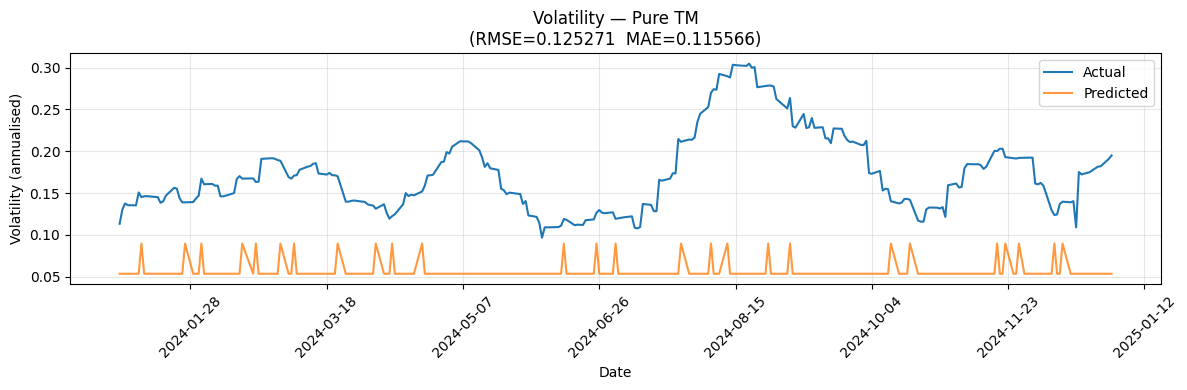

In [ ]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=False, model='tsetlin', tune = False, feature_selection = False,
    use_scaling=True, hybrid = False
)
# {'number_of_clauses': 143, 'T': 383, 's': 8.394129005949551}

Total: 8774 | Train: 8522 | Test: 252 | Features: 69

[Pure TM — no baseline model]


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 10 are removed. Consider decreasing the number of bins.
  warnings.warn(



Pure TM (no baseline)
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.143777   0.030557
2024-02-01          0.167210     0.071515   0.095695
2024-03-04          0.169070     0.125712   0.043359
2024-04-03          0.135562     0.125712   0.009850
2024-05-02          0.197198     0.125712   0.071486
2024-06-03          0.121509     0.125712   0.004202
2024-07-03          0.119741     0.125712   0.005971
2024-08-02          0.244631     0.125712   0.118919
2024-09-03          0.251129     0.125712   0.125417
2024-10-02          0.212546     0.125712   0.086835
2024-10-31          0.121384     0.125712   0.004327
2024-12-02          0.192293     0.143777   0.048516
  (showing every ~21 days)
-----------------------------------------------------------------
                                         MAE: 0.052199
                                        RMSE: 0.067636
                   

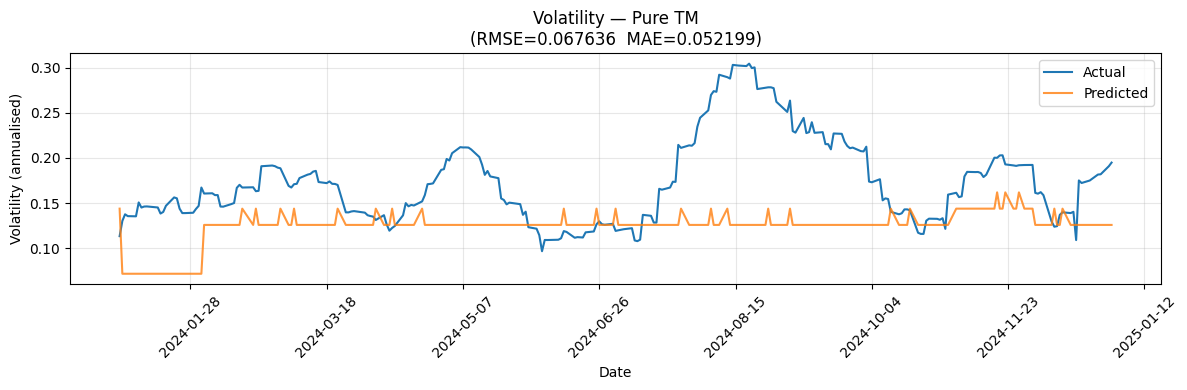

In [ ]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=True, model='tsetlin', tune = False,
    use_scaling=True, hybrid = False
)

### residual TM

Total: 8774 | Train: 8522 | Test: 252 | Features: 22


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(



XGB+TM
Base RMSE: 0.020044  →  Final RMSE: 0.019934
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.112996   0.000224
2024-02-01          0.167210     0.156733   0.010477
2024-03-04          0.169070     0.153491   0.015579
2024-04-03          0.135562     0.134637   0.000925
2024-05-02          0.197198     0.190256   0.006942
2024-06-03          0.121509     0.153097   0.031588
2024-07-03          0.119741     0.129984   0.010243
2024-08-02          0.244631     0.229986   0.014645
2024-09-03          0.251129     0.246533   0.004596
2024-10-02          0.212546     0.204886   0.007660
2024-10-31          0.121384     0.147123   0.025739
2024-12-02          0.192293     0.148538   0.043755
  (showing every ~21 days)
-----------------------------------------------------------------
                                         MAE: 0.016080
                                        RMSE

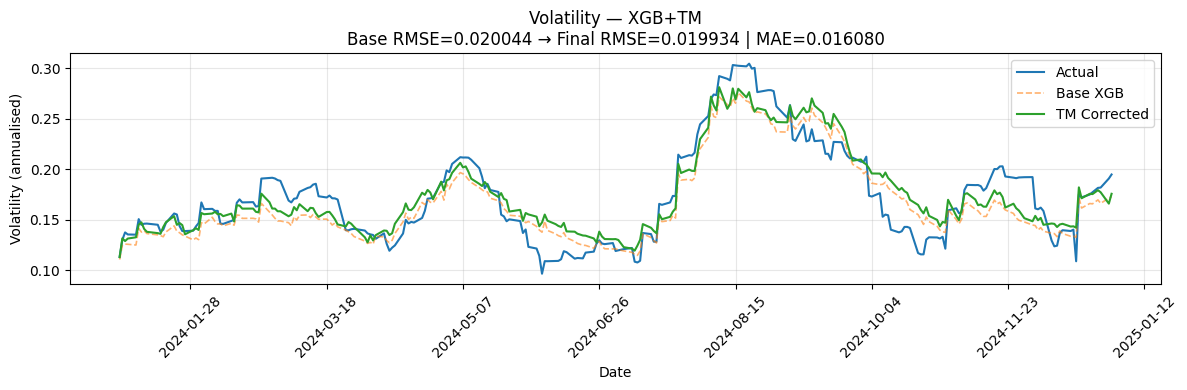

In [ ]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=False, model='tsetlin', tune = False,
    use_scaling=True, hybrid = True
)
# {'number_of_clauses': 65, 'T': 58, 's': 8.985469090010296}

Total: 8774 | Train: 8522 | Test: 252 | Features: 69


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 10 are removed. Consider decreasing the number of bins.
  warnings.warn(



XGB+TM
Base RMSE: 0.019784  →  Final RMSE: 0.020163
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.107336   0.005884
2024-02-01          0.167210     0.142813   0.024397
2024-03-04          0.169070     0.154337   0.014733
2024-04-03          0.135562     0.127039   0.008523
2024-05-02          0.197198     0.178266   0.018932
2024-06-03          0.121509     0.142628   0.021119
2024-07-03          0.119741     0.131734   0.011993
2024-08-02          0.244631     0.221555   0.023076
2024-09-03          0.251129     0.235519   0.015610
2024-10-02          0.212546     0.201086   0.011461
2024-10-31          0.121384     0.129543   0.008158
2024-12-02          0.192293     0.142118   0.050175
  (showing every ~21 days)
-----------------------------------------------------------------
                                         MAE: 0.016841
                                        RMSE

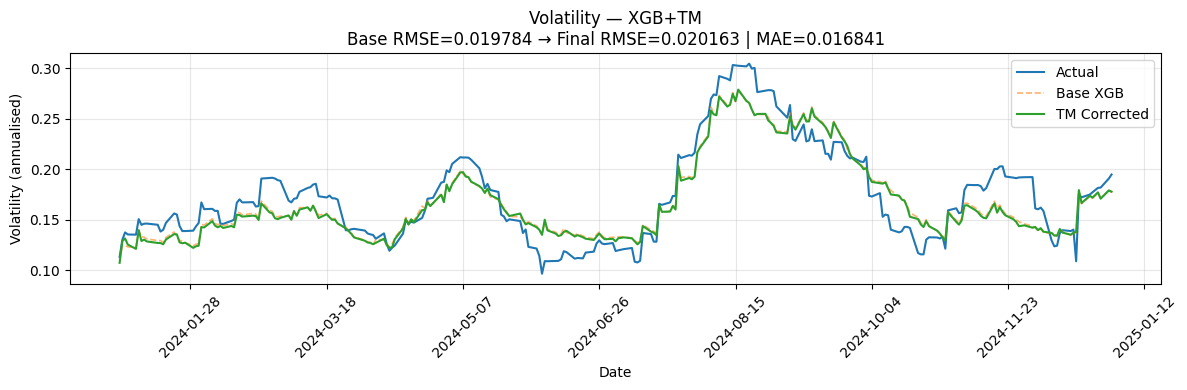

In [ ]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=True, model='tsetlin', tune = False,
    use_scaling=True, hybrid = True
)

### Tselin +SHAP

Total: 8774 | Train: 8522 | Test: 252 | Features: 22

[Optuna Tuning]


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
[I 2026-09-01 12:28:17,074] A new study created in memory with name: no-name-473d3e1f-7141-4ebe-a4d0-384d3796e83a



  SHAP-guided bins — min:5 max:30 mean:6.7


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-01 12:28:28,822] Trial 0 finished with value: 0.0381574326479538 and parameters: {'number_of_clauses': 780, 'T': 476, 's': 7.587945476302646}. Best is trial 0 with value: 0.0381574326479538.
[I 2026-09-01 12:28:41,669] Trial 1 finished with value: 0.6603581723522964 and parameters: {'number_of_clauses': 1217, 'T': 86, 's': 2.403950683025824}. Best is trial 0 with value: 0.0381574326479538.
[I 2026-09-01 12:28:51,575] Trial 2 finished with value: 0.022995171043163475 and parameters: {'number_of_clauses': 163, 'T': 435, 's': 6.41003510568888}. Best is trial 2 with value: 0.022995171043163475.
[I 2026-09-01 12:29:04,065] Trial 3 finished with value: 3.4347648142520084 and parameters: {'number_of_clauses': 1431, 'T': 20, 's': 9.72918866945795}. Best is trial 2 with value: 0.022995171043163475.
[I 2026-09-01 12:29:18,085] Trial 4 finished with value: 0.7026245667531406 and parameters: {'number_of_clauses': 1674, 'T': 114, 's': 2.636424704863906}. Best is trial 2 with value: 0.022

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(



XGB+TM + SHAP
Base RMSE: 0.020044  →  Final RMSE: 0.019478
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.111067   0.002153
2024-02-01          0.167210     0.145565   0.021646
2024-03-04          0.169070     0.149758   0.019312
2024-04-03          0.135562     0.128263   0.007299
2024-05-02          0.197198     0.179691   0.017507
2024-06-03          0.121509     0.143307   0.021798
2024-07-03          0.119741     0.120797   0.001057
2024-08-02          0.244631     0.220886   0.023745
2024-09-03          0.251129     0.237691   0.013437
2024-10-02          0.212546     0.198425   0.014121
2024-10-31          0.121384     0.140350   0.018966
2024-12-02          0.192293     0.151754   0.040539
  (showing every ~21 days)
-----------------------------------------------------------------
                                         MAE: 0.016155
                                     

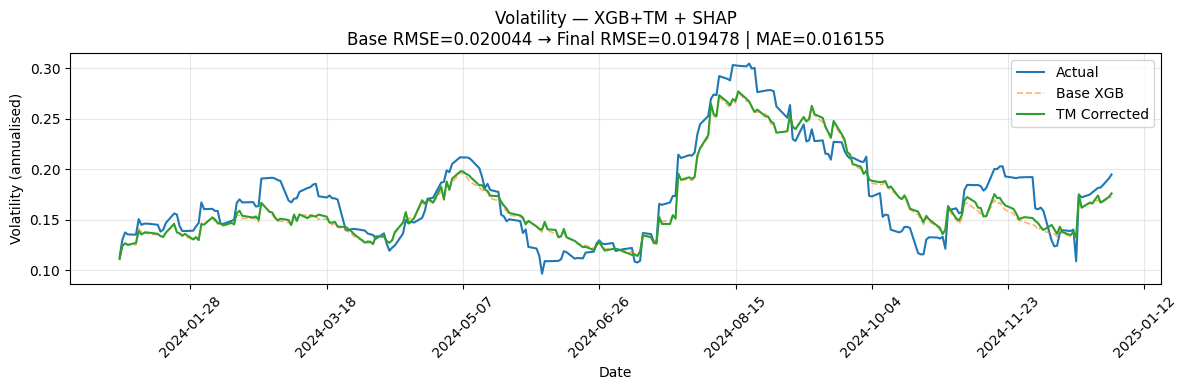

In [ ]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=False, model='tsetlin', tune = True,
    use_scaling=True, shap_binarise = True
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69

[Optuna Tuning]


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
[I 2026-09-01 12:34:15,737] A new study created in memory with name: no-name-93df3f8a-64f3-4443-b323-03c4d74972e0



  SHAP-guided bins — min:5 max:30 mean:5.8


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-01 12:34:29,568] Trial 0 finished with value: 0.018546112645293992 and parameters: {'number_of_clauses': 780, 'T': 476, 's': 7.587945476302646}. Best is trial 0 with value: 0.018546112645293992.
[I 2026-09-01 12:34:43,889] Trial 1 finished with value: 0.6163852161062913 and parameters: {'number_of_clauses': 1217, 'T': 86, 's': 2.403950683025824}. Best is trial 0 with value: 0.018546112645293992.
[I 2026-09-01 12:34:53,694] Trial 2 finished with value: 0.023279638180605914 and parameters: {'number_of_clauses': 163, 'T': 435, 's': 6.41003510568888}. Best is trial 0 with value: 0.018546112645293992.
[I 2026-09-01 12:35:08,395] Trial 3 finished with value: 3.0533191318542623 and parameters: {'number_of_clauses': 1431, 'T': 20, 's': 9.72918866945795}. Best is trial 0 with value: 0.018546112645293992.
[I 2026-09-01 12:35:25,363] Trial 4 finished with value: 0.6316174419727709 and parameters: {'number_of_clauses': 1674, 'T': 114, 's': 2.636424704863906}. Best is trial 0 with value:

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(



XGB+TM + SHAP
Base RMSE: 0.019784  →  Final RMSE: 0.019080
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.115751   0.002531
2024-02-01          0.167210     0.149725   0.017485
2024-03-04          0.169070     0.157646   0.011424
2024-04-03          0.135562     0.132961   0.002601
2024-05-02          0.197198     0.182809   0.014388
2024-06-03          0.121509     0.146388   0.024879
2024-07-03          0.119741     0.135005   0.015264
2024-08-02          0.244631     0.224085   0.020546
2024-09-03          0.251129     0.237825   0.013304
2024-10-02          0.212546     0.203540   0.009007
2024-10-31          0.121384     0.139973   0.018589
2024-12-02          0.192293     0.148297   0.043996
  (showing every ~21 days)
-----------------------------------------------------------------
                                         MAE: 0.015913
                                     

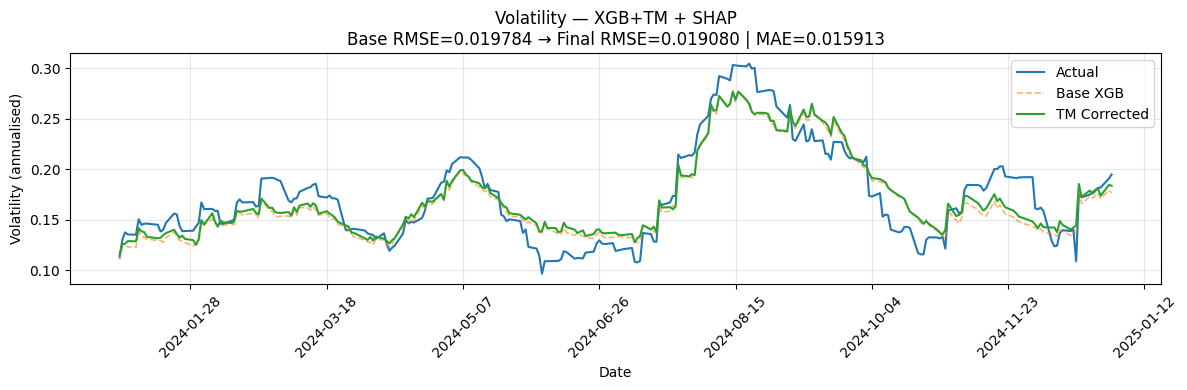

In [ ]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=True, model='tsetlin', tune = True,
    use_scaling=True, feature_selection=False, importance_strategy='lime', shap_binarise = True
)

### TM + SHAP + Regime

Total: 8774 | Train: 8522 | Test: 252 | Features: 22

[Regime Detection]
  HMM regimes — Expansion: 5128q | Stress/Recession: 3394q
  Features used: ['volatility_lag1']

[Optuna Tuning]


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
[I 2026-09-01 12:40:38,928] A new study created in memory with name: no-name-3311787a-89ce-4fc7-960b-c0512b1cb4ba



  SHAP-guided bins — min:5 max:30 mean:6.7


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-01 12:40:51,039] Trial 0 finished with value: 0.0381574326479538 and parameters: {'number_of_clauses': 780, 'T': 476, 's': 7.587945476302646}. Best is trial 0 with value: 0.0381574326479538.
[I 2026-09-01 12:41:03,694] Trial 1 finished with value: 0.6603581723522964 and parameters: {'number_of_clauses': 1217, 'T': 86, 's': 2.403950683025824}. Best is trial 0 with value: 0.0381574326479538.
[I 2026-09-01 12:41:11,988] Trial 2 finished with value: 0.022995171043163475 and parameters: {'number_of_clauses': 163, 'T': 435, 's': 6.41003510568888}. Best is trial 2 with value: 0.022995171043163475.
[I 2026-09-01 12:41:24,119] Trial 3 finished with value: 3.4347648142520084 and parameters: {'number_of_clauses': 1431, 'T': 20, 's': 9.72918866945795}. Best is trial 2 with value: 0.022995171043163475.
[I 2026-09-01 12:41:37,759] Trial 4 finished with value: 0.7026245667531406 and parameters: {'number_of_clauses': 1674, 'T': 114, 's': 2.636424704863906}. Best is trial 2 with value: 0.022

...


  SHAP-guided bins — min:5 max:30 mean:6.7


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(



  SHAP-guided bins — min:5 max:30 mean:6.7


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(



XGB+TM + SHAP + Regime
Base RMSE: 0.020044  →  Final RMSE: 0.020966
Date                  Actual    Predicted      Error   Regime
-----------------------------------------------------------------
2024-01-02          0.113220     0.107573   0.005647   Stress
2024-02-01          0.167210     0.144312   0.022899   Stress
2024-03-04          0.169070     0.142989   0.026081   Stress
2024-04-03          0.135562     0.125889   0.009673   Stress
2024-05-02          0.197198     0.179127   0.018071   Stress
2024-06-03          0.121509     0.144726   0.023217   Stress
2024-07-03          0.119741     0.119631   0.000110   Stress
2024-08-02          0.244631     0.219633   0.024998   Stress
2024-09-03          0.251129     0.236180   0.014949   Stress
2024-10-02          0.212546     0.196311   0.016236   Stress
2024-10-31          0.121384     0.133323   0.011938   Stress
2024-12-02          0.192293     0.140676   0.051618   Stress
  (showing every ~21 days)
--------------------------------

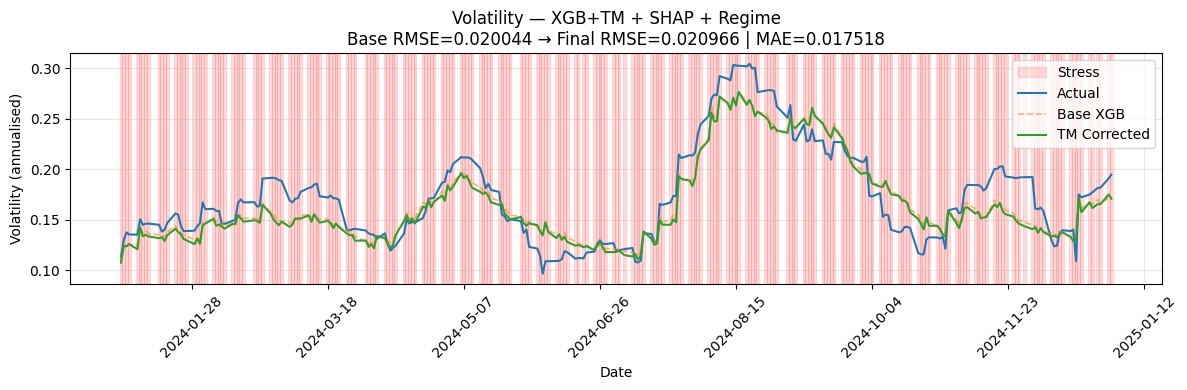

In [ ]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=True, feature_selection=False, importance_strategy='lime', shap_binarise = True, use_regime = True
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69

[Regime Detection]
  HMM regimes — Expansion: 5128q | Stress/Recession: 3394q
  Features used: ['volatility_lag1']

[Optuna Tuning]


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
[I 2026-09-01 12:50:43,597] A new study created in memory with name: no-name-abfd1dc7-2006-4d4f-8095-30e4b3223e76



  SHAP-guided bins — min:5 max:30 mean:5.8


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-01 12:50:56,848] Trial 0 finished with value: 0.018546112645293992 and parameters: {'number_of_clauses': 780, 'T': 476, 's': 7.587945476302646}. Best is trial 0 with value: 0.018546112645293992.
[I 2026-09-01 12:51:10,559] Trial 1 finished with value: 0.6163852161062913 and parameters: {'number_of_clauses': 1217, 'T': 86, 's': 2.403950683025824}. Best is trial 0 with value: 0.018546112645293992.
[I 2026-09-01 12:51:20,535] Trial 2 finished with value: 0.023279638180605914 and parameters: {'number_of_clauses': 163, 'T': 435, 's': 6.41003510568888}. Best is trial 0 with value: 0.018546112645293992.
[I 2026-09-01 12:51:34,228] Trial 3 finished with value: 3.0533191318542623 and parameters: {'number_of_clauses': 1431, 'T': 20, 's': 9.72918866945795}. Best is trial 0 with value: 0.018546112645293992.
[I 2026-09-01 12:51:49,474] Trial 4 finished with value: 0.6316174419727709 and parameters: {'number_of_clauses': 1674, 'T': 114, 's': 2.636424704863906}. Best is trial 0 with value:

...


  SHAP-guided bins — min:5 max:30 mean:5.8


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(



  SHAP-guided bins — min:5 max:30 mean:5.9


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(



XGB+TM + SHAP + Regime
Base RMSE: 0.019784  →  Final RMSE: 0.020749
Date                  Actual    Predicted      Error   Regime
-----------------------------------------------------------------
2024-01-02          0.113220     0.112250   0.000970   Stress
2024-02-01          0.167210     0.150252   0.016958   Stress
2024-03-04          0.169070     0.152580   0.016490   Stress
2024-04-03          0.135562     0.129349   0.006213   Stress
2024-05-02          0.197198     0.178526   0.018672   Stress
2024-06-03          0.121509     0.145125   0.023616   Stress
2024-07-03          0.119741     0.133742   0.014001   Stress
2024-08-02          0.244631     0.219578   0.025053   Stress
2024-09-03          0.251129     0.237792   0.013336   Stress
2024-10-02          0.212546     0.203731   0.008816   Stress
2024-10-31          0.121384     0.130767   0.009383   Stress
2024-12-02          0.192293     0.138756   0.053537   Stress
  (showing every ~21 days)
--------------------------------

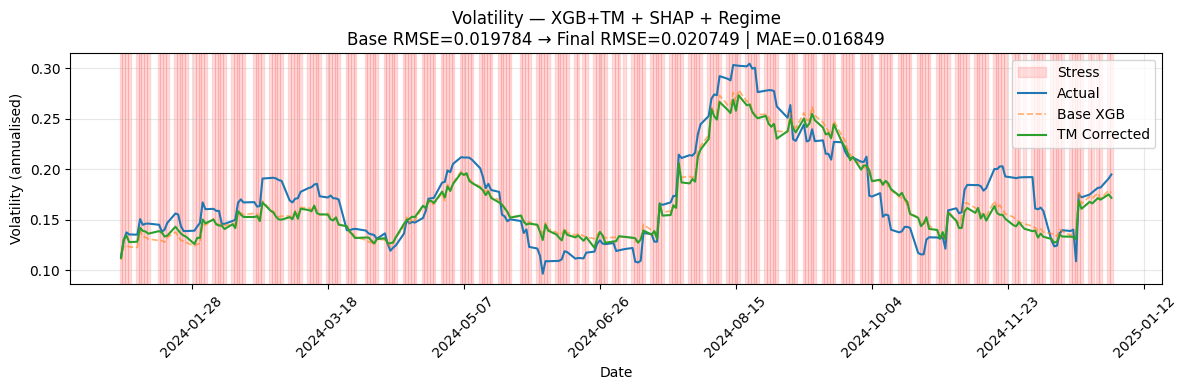

In [ ]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=True, feature_selection=False, importance_strategy='lime', shap_binarise = True, use_regime = True
)

### bayes

[I 2026-09-17 18:20:34,619] A new study created in memory with name: no-name-3a07f32b-13e9-4ef7-9f8a-49b3427b3dc8


Total: 8774 | Train: 8522 | Test: 252 | Features: 22

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-17 18:20:39,275] Trial 0 finished with value: 0.9425554864239081 and parameters: {'alpha_1': 7.459343285726542e-07, 'alpha_2': 0.0005669849511478851, 'lambda_1': 4.570563099801451e-05, 'lambda_2': 9.846738873614555e-06, 'max_iter': 480}. Best is trial 0 with value: 0.9425554864239081.
[I 2026-09-17 18:20:39,662] Trial 1 finished with value: 0.9425662908111716 and parameters: {'alpha_1': 6.02521573620385e-08, 'alpha_2': 1.951722464144948e-08, 'lambda_1': 0.00021423021757741048, 'lambda_2': 1.0129197956845722e-05, 'max_iter': 1475}. Best is trial 1 with value: 0.9425662908111716.
[I 2026-09-17 18:20:40,036] Trial 2 finished with value: 0.9425465944195235 and parameters: {'alpha_1': 1.2674255898937194e-08, 'alpha_2': 0.0007072114131472234, 'lambda_1': 0.00014528246637516033, 'lambda_2': 1.1526449540315595e-07, 'max_iter': 527}. Best is trial 1 with value: 0.9425662908111716.
[I 2026-09-17 18:20:40,415] Trial 3 finished with value: 0.9425607881338515 and parameters: {'alpha_1': 

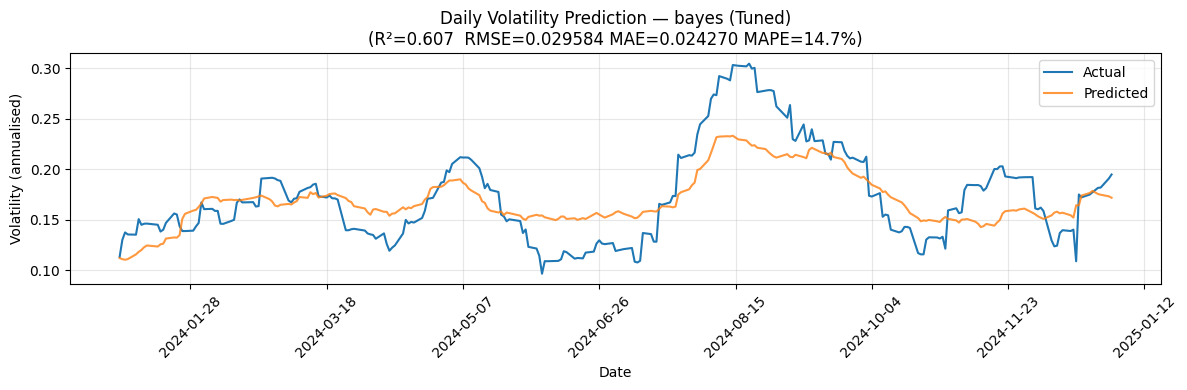

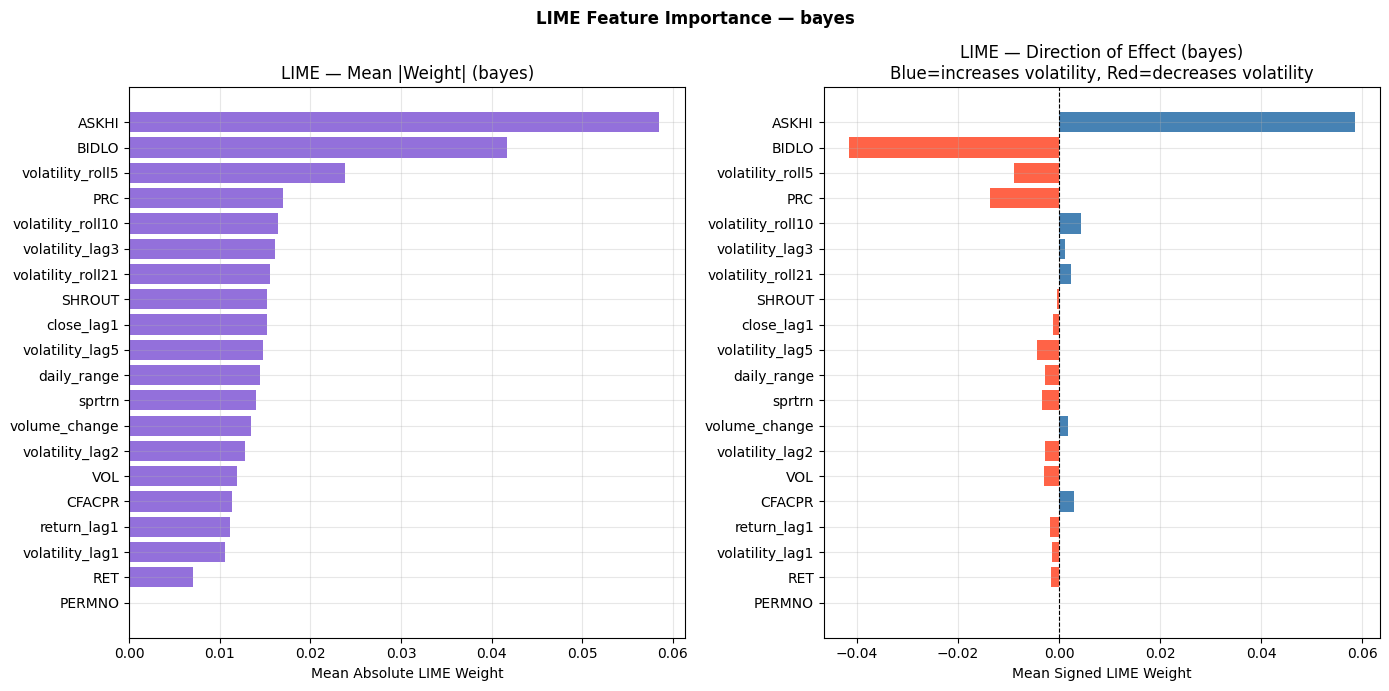

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_std, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime = Volatility_prediction(
    df, use_macro=False, model='bayes',
    use_scaling=True, importance_strategy='lime'
)

[I 2026-09-17 18:41:26,458] A new study created in memory with name: no-name-e76e9c25-b143-40e1-870e-effeaa237342


Total: 8774 | Train: 8522 | Test: 252 | Features: 69

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-17 18:41:28,417] Trial 0 finished with value: 0.981816635009579 and parameters: {'alpha_1': 7.459343285726542e-07, 'alpha_2': 0.0005669849511478851, 'lambda_1': 4.570563099801451e-05, 'lambda_2': 9.846738873614555e-06, 'max_iter': 480}. Best is trial 0 with value: 0.981816635009579.
[I 2026-09-17 18:41:28,684] Trial 1 finished with value: 0.981816704233043 and parameters: {'alpha_1': 6.02521573620385e-08, 'alpha_2': 1.951722464144948e-08, 'lambda_1': 0.00021423021757741048, 'lambda_2': 1.0129197956845722e-05, 'max_iter': 1475}. Best is trial 1 with value: 0.981816704233043.
[I 2026-09-17 18:41:28,961] Trial 2 finished with value: 0.9818165764137545 and parameters: {'alpha_1': 1.2674255898937194e-08, 'alpha_2': 0.0007072114131472234, 'lambda_1': 0.00014528246637516033, 'lambda_2': 1.1526449540315595e-07, 'max_iter': 527}. Best is trial 1 with value: 0.981816704233043.
[I 2026-09-17 18:41:29,248] Trial 3 finished with value: 0.9818166681422262 and parameters: {'alpha_1': 8.260

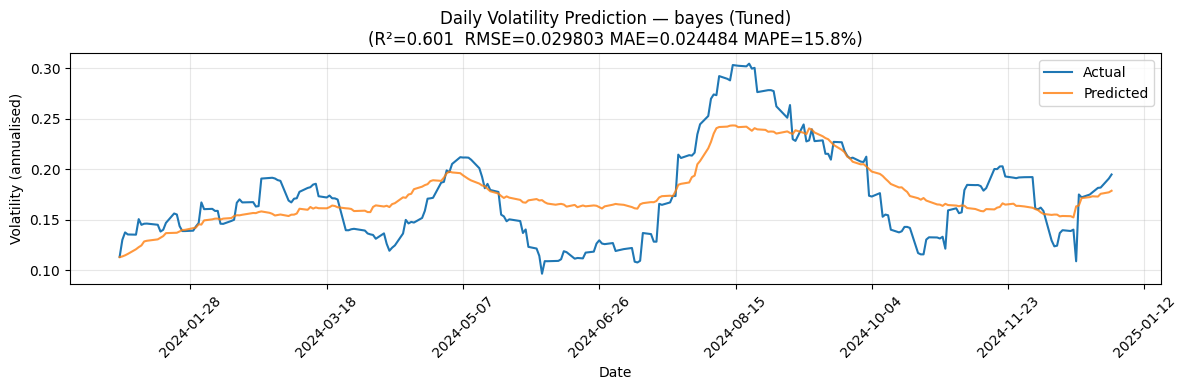

  0%|          | 0/8522 [00:00<?, ?it/s]

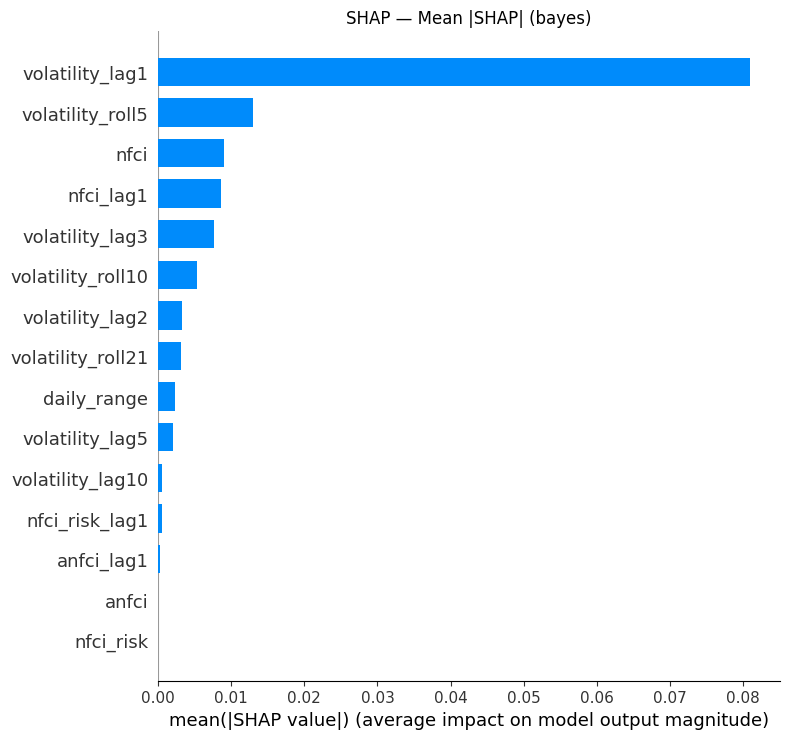

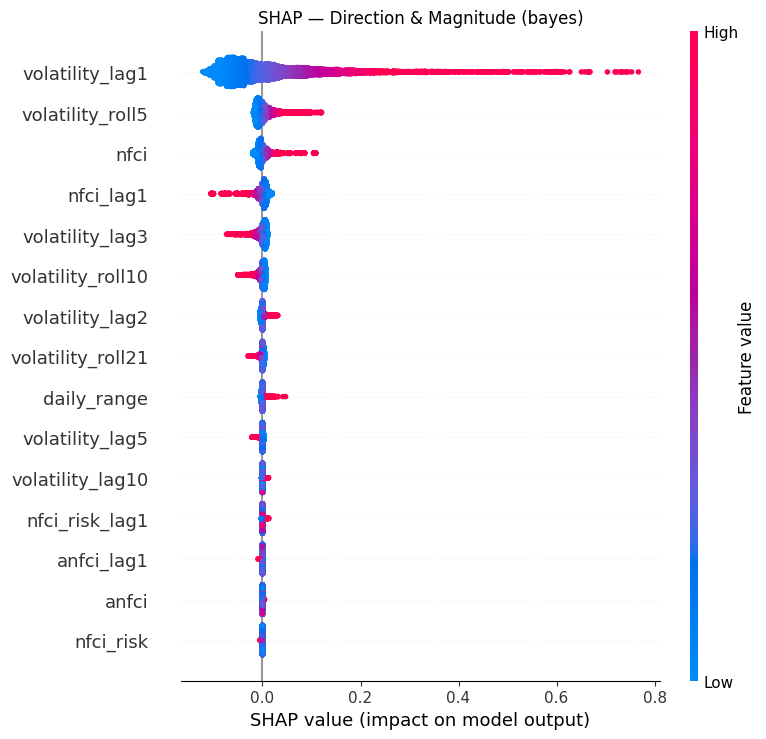

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_std, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime = Volatility_prediction(
    df, use_macro=True, model='bayes', feature_selection=True,
    use_scaling=True, importance_strategy='shap', tune=True
)

### GB

Total: 8774 | Train: 8522 | Test: 252 | Features: 22
['PERMNO', 'BIDLO', 'ASKHI', 'PRC', 'VOL', 'RET', 'SHROUT', 'CFACPR', 'RETX', 'sprtrn', 'daily_range', 'volume_change', 'close_lag1', 'return_lag1', 'volatility_lag1', 'volatility_lag2', 'volatility_lag3', 'volatility_lag5', 'volatility_lag10', 'volatility_roll5', 'volatility_roll10', 'volatility_roll21']

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.108489     0.004731
2024-02-01          0.167210     0.143435     0.023775
2024-03-04          0.169070     0.143503     0.025567
2024-04-03          0.135562     0.115067     0.020495
2024-05-02          0.197198     0.182885     0.014313
2024-06-03          0.121509     0.135465     0.013956
2024-07-03          0.119741     0.125146     0.005405
2024-08-02          0.244631     0.225207     0.019424
2024-09-03          0.251129     0.238809     0.012320
2024-10-02          0.2

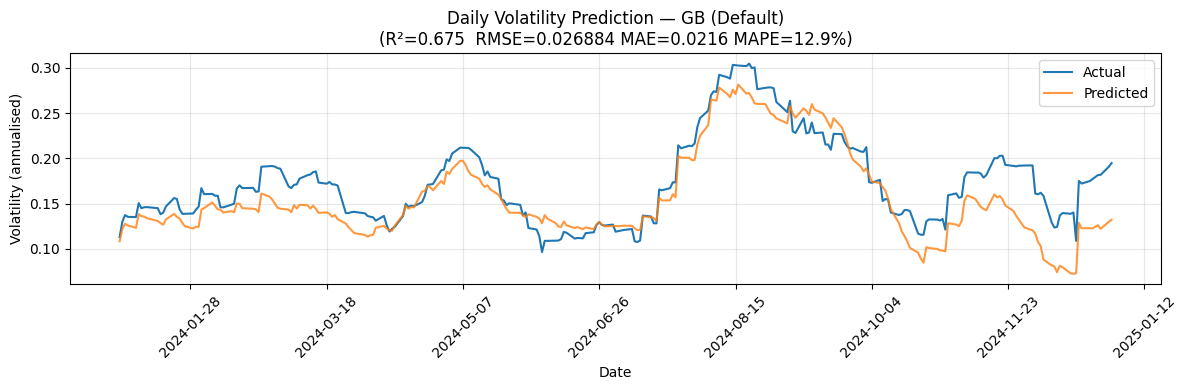

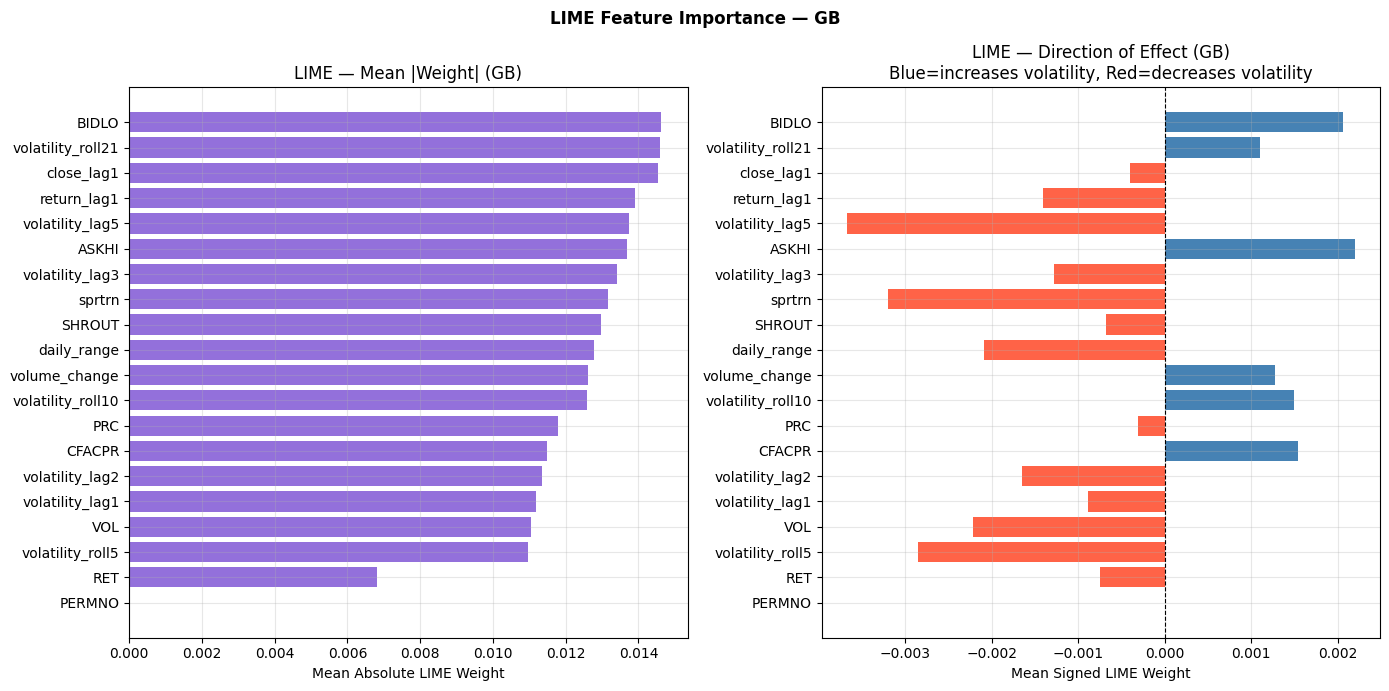

In [ ]:
results, rmse, mae, mape, r2, gb_fi_std, gb_fi_shap, gb_fi_perm, gb_fi_lime = Volatility_prediction(
    df, use_macro=False, model='GB', importance_strategy='lime',
    use_scaling=True, tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.108525     0.004695
2024-02-01          0.167210     0.143759     0.023451
2024-03-04          0.169070     0.147234     0.021836
2024-04-03          0.135562     0.124206     0.011356
2024-05-02          0.197198     0.189607     0.007590
2024-06-03          0.121509     0.137151     0.015642
2024-07-03          0.119741     0.123646     0.003905
2024-08-02          0.244631     0.225384     0.019246
2024-09-03          0.251129     0.240381     0.010748
2024-10-02          0.212546     0.198895     0.013652
2024-10-31          0.121384     0.089382     0.032002
2024-12-02          0.192293     0.113434     0.078860
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.028380
             

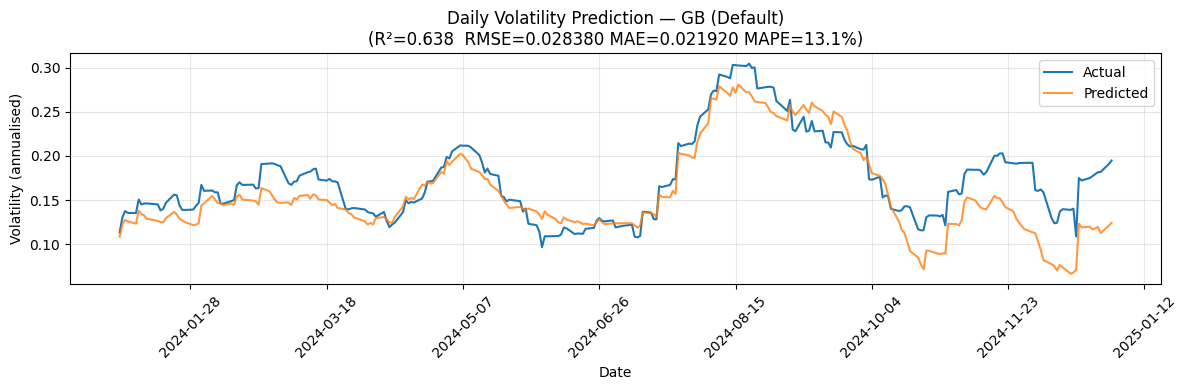

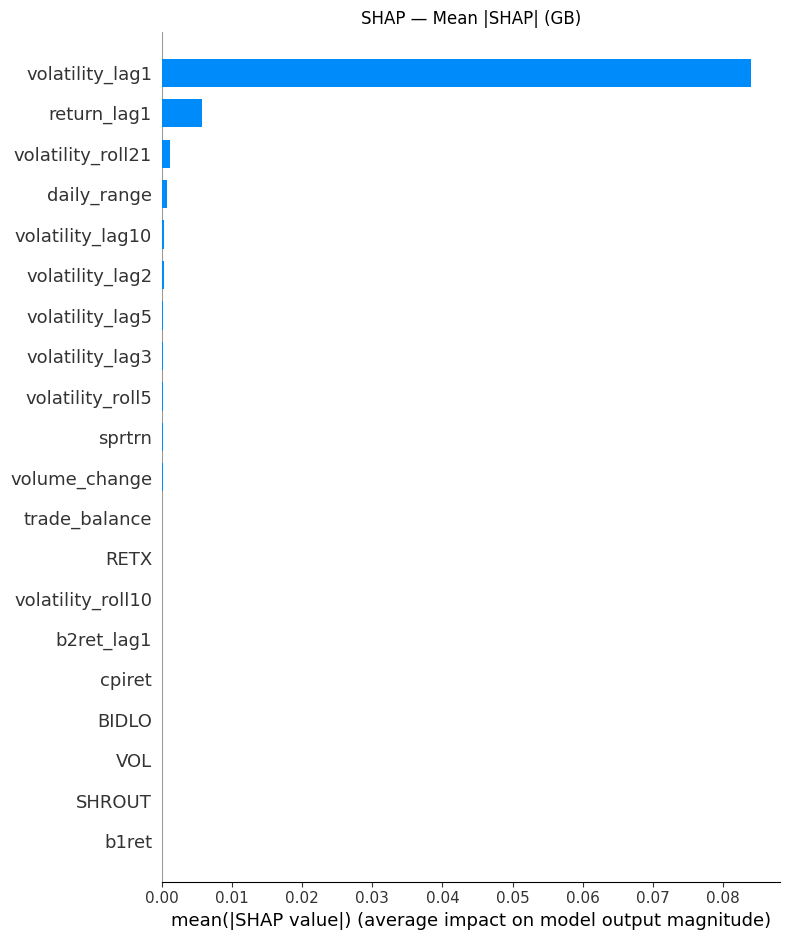

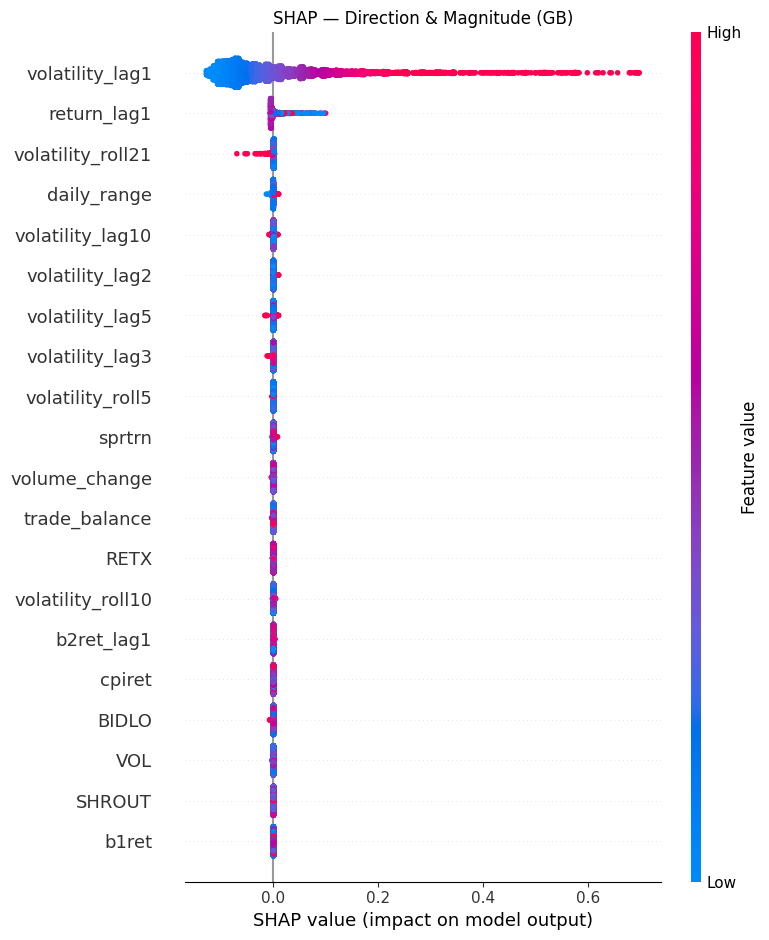

In [ ]:
results, rmse, mae, mape, r2, gb_fi_std, gb_fi_shap, gb_fi_perm, gb_fi_lime = Volatility_prediction(
    df, use_macro=True, model='GB', importance_strategy='shap',
    use_scaling=True, tune = False
)

### XGB

Total: 8774 | Train: 8522 | Test: 252 | Features: 22

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.110613     0.002607
2024-02-01          0.167210     0.147093     0.020117
2024-03-04          0.169070     0.147149     0.021921
2024-04-03          0.135562     0.127636     0.007926
2024-05-02          0.197198     0.180615     0.016582
2024-06-03          0.121509     0.143456     0.021947
2024-07-03          0.119741     0.120343     0.000603
2024-08-02          0.244631     0.220346     0.024285
2024-09-03          0.251129     0.236892     0.014236
2024-10-02          0.212546     0.197885     0.014661
2024-10-31          0.121384     0.137483     0.016099
2024-12-02          0.192293     0.144836     0.047458
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.020044
             

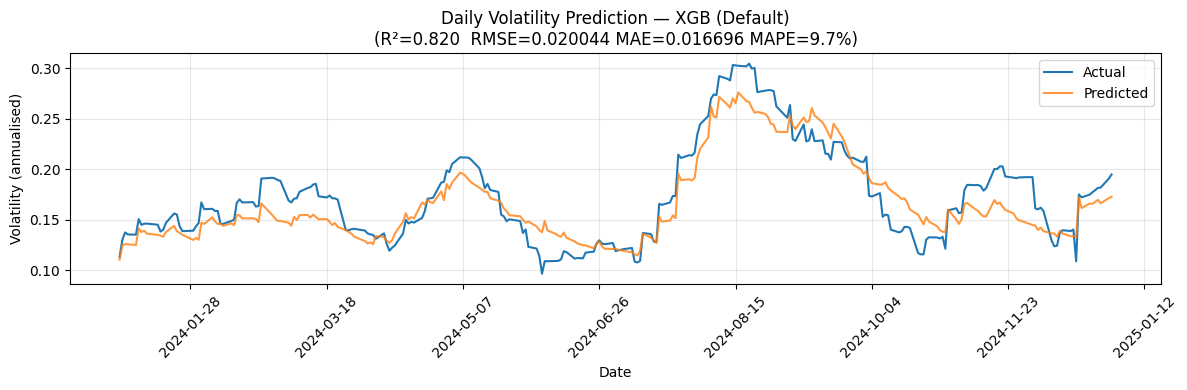

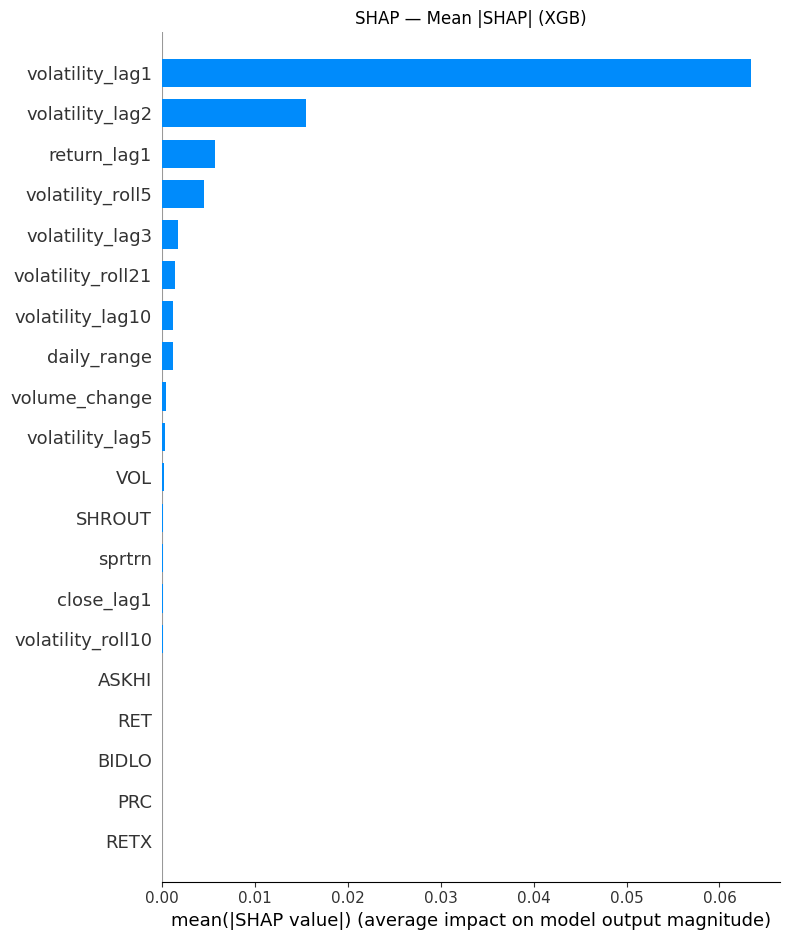

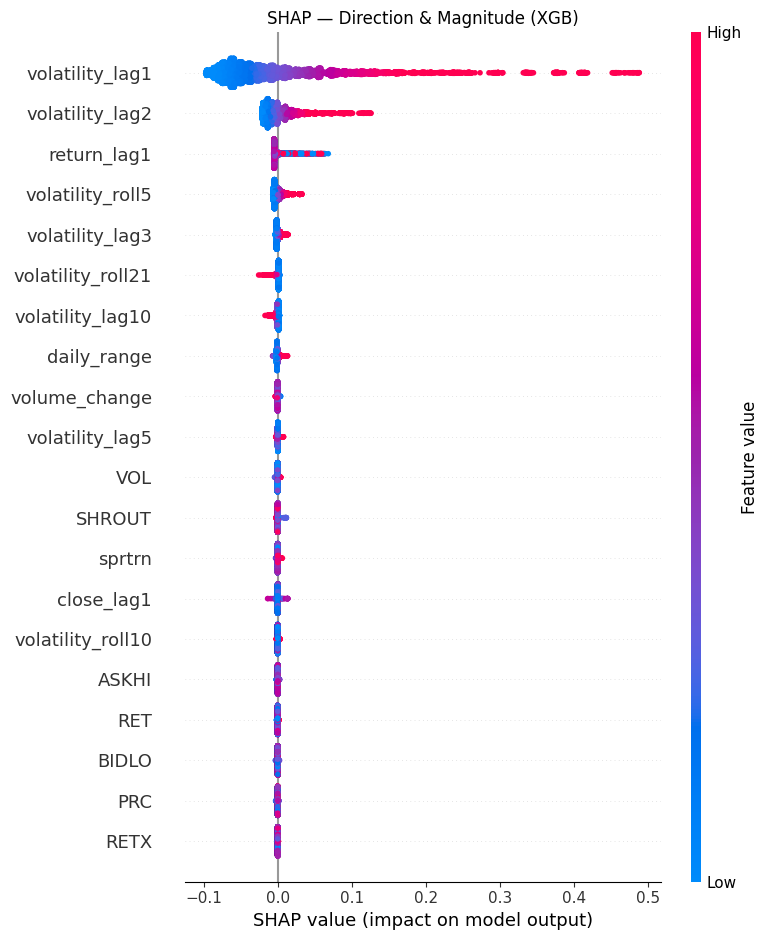

In [ ]:
results, rmse, mae, mape, r2, xgb_fi_std, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime = Volatility_prediction(
    df,
    use_macro        = False,
    model            = 'XGB',
    use_scaling      = True,
    importance_strategy = 'shap',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.111150     0.002070
2024-02-01          0.167210     0.147698     0.019512
2024-03-04          0.169070     0.148302     0.020768
2024-04-03          0.135562     0.126220     0.009342
2024-05-02          0.197198     0.193451     0.003747
2024-06-03          0.121509     0.143674     0.022164
2024-07-03          0.119741     0.127832     0.008092
2024-08-02          0.244631     0.228118     0.016513
2024-09-03          0.251129     0.236904     0.014225
2024-10-02          0.212546     0.207517     0.005030
2024-10-31          0.121384     0.135979     0.014595
2024-12-02          0.192293     0.152095     0.040198
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.020131
             

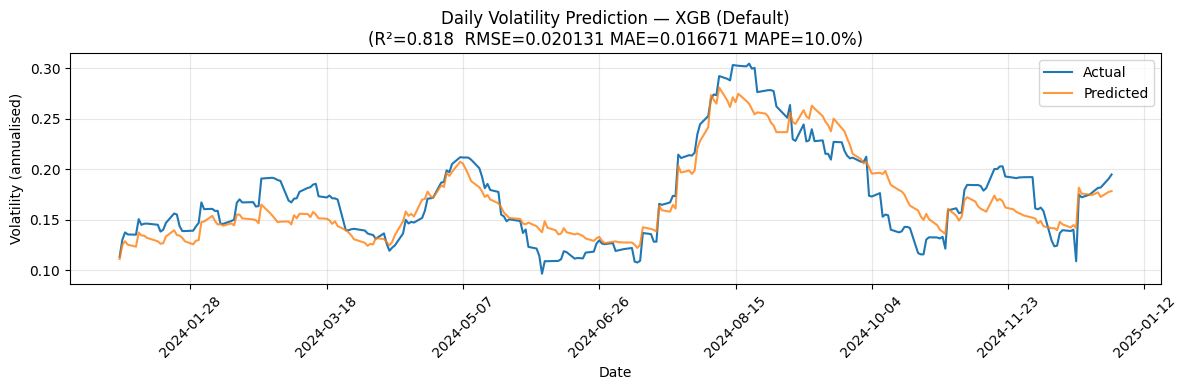

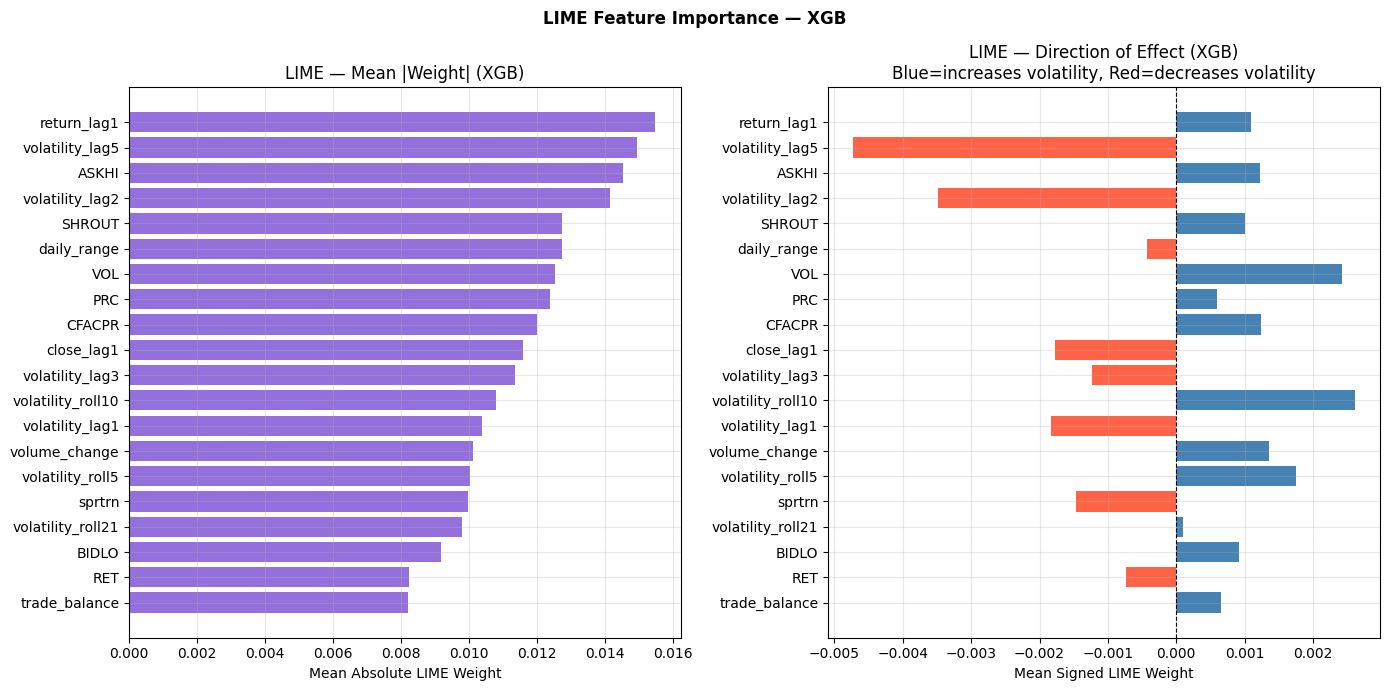

In [ ]:
results, rmse, mae, mape, r2, xgb_fi_std, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime = Volatility_prediction(
    df,
    use_macro        = True,
    model            = 'XGB',
    use_scaling      = True,
    importance_strategy = 'lime',
    tune=False
)

### KNN

Total: 8774 | Train: 8522 | Test: 252 | Features: 22

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.104721     0.008499
2024-02-01          0.167210     0.147870     0.019340
2024-03-04          0.169070     0.123922     0.045148
2024-04-03          0.135562     0.118369     0.017193
2024-05-02          0.197198     0.129266     0.067932
2024-06-03          0.121509     0.108682     0.012828
2024-07-03          0.119741     0.106333     0.013408
2024-08-02          0.244631     0.140377     0.104254
2024-09-03          0.251129     0.140220     0.110908
2024-10-02          0.212546     0.121344     0.091202
2024-10-31          0.121384     0.122635     0.001251
2024-12-02          0.192293     0.117610     0.074683
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.064831
             

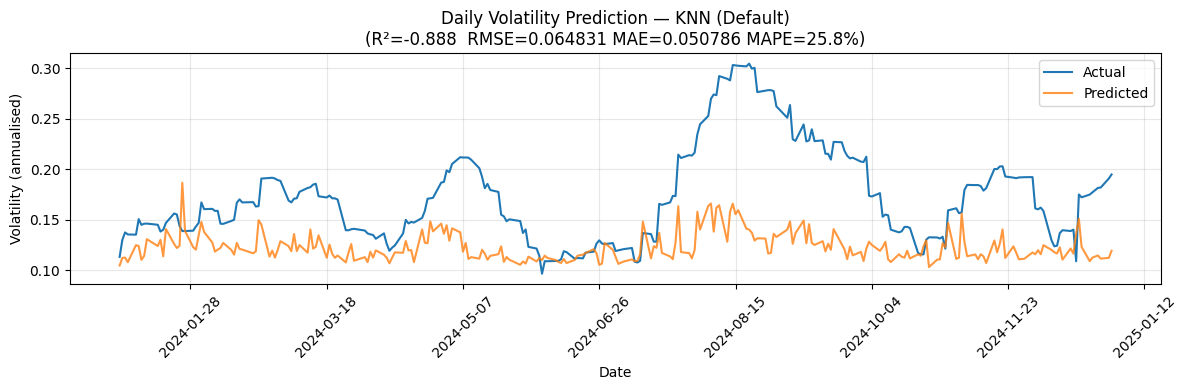

  0%|          | 0/8522 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results, rmse, mae, mape, r2, knn_fi_std, knn_fi_shap, knn_fi_perm, knn_fi_lime = Volatility_prediction(
    df,
    use_macro        = False,
    model            = 'KNN',
    use_scaling      = True,
    importance_strategy = 'shap',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.129801     0.016581
2024-02-01          0.167210     0.159140     0.008070
2024-03-04          0.169070     0.173379     0.004309
2024-04-03          0.135562     0.165288     0.029726
2024-05-02          0.197198     0.129255     0.067943
2024-06-03          0.121509     0.132187     0.010678
2024-07-03          0.119741     0.110757     0.008984
2024-08-02          0.244631     0.130507     0.114123
2024-09-03          0.251129     0.131799     0.119329
2024-10-02          0.212546     0.165855     0.046692
2024-10-31          0.121384     0.164725     0.043341
2024-12-02          0.192293     0.158993     0.033300
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.064794
             

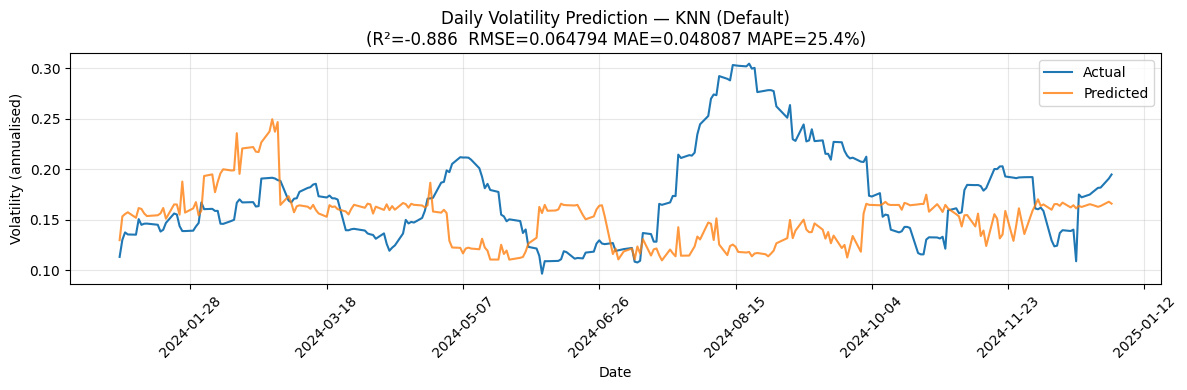

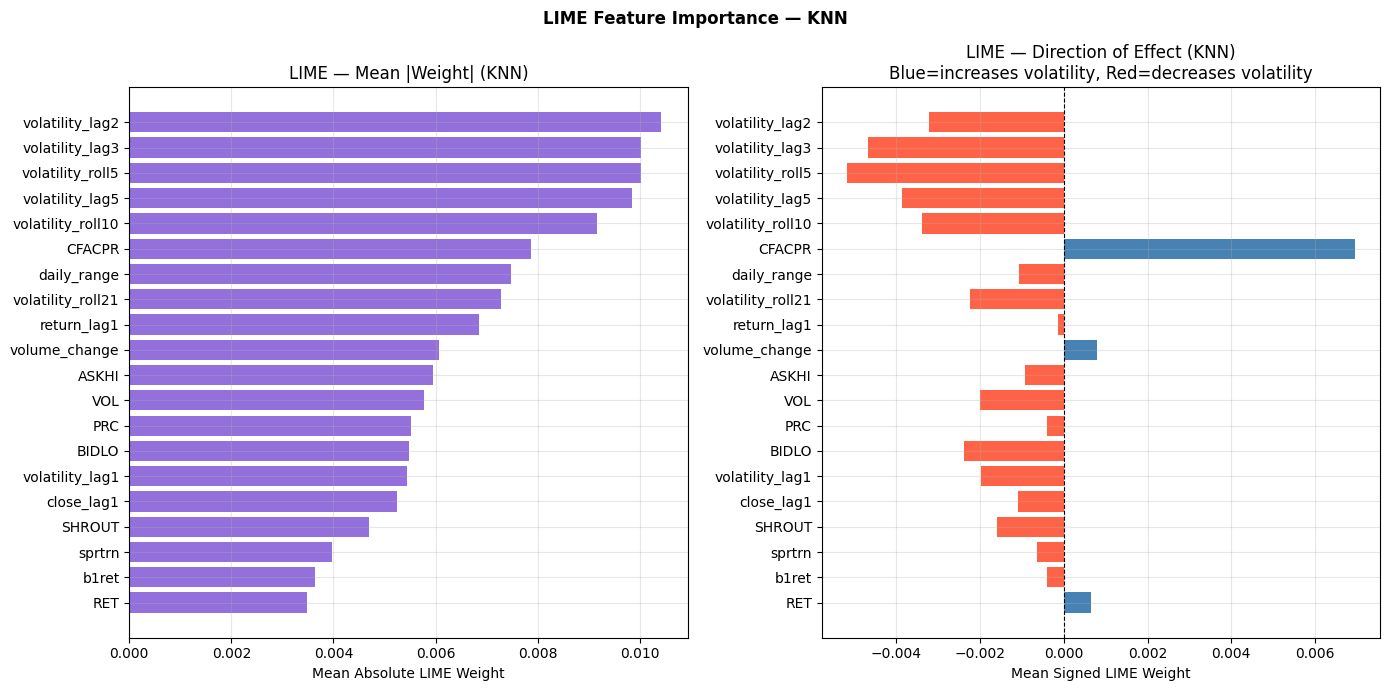

In [ ]:
results, rmse, mae, mape, r2, knn_fi_std, knn_fi_shap, knn_fi_perm, knn_fi_lime = Volatility_prediction(
    df,
    use_macro        = True,
    model            = 'KNN',
    use_scaling      = True,
    importance_strategy = 'lime',
    tune=False
)

### SVR

Total: 8774 | Train: 8522 | Test: 252 | Features: 22

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.111475     0.001745
2024-02-01          0.167210     0.210436     0.043226
2024-03-04          0.169070     0.213113     0.044042
2024-04-03          0.135562     0.136110     0.000548
2024-05-02          0.197198     0.236694     0.039496
2024-06-03          0.121509     0.115455     0.006055
2024-07-03          0.119741     0.151923     0.032182
2024-08-02          0.244631     0.282482     0.037851
2024-09-03          0.251129     0.174522     0.076607
2024-10-02          0.212546     0.171281     0.041265
2024-10-31          0.121384     0.193654     0.072270
2024-12-02          0.192293     0.196833     0.004539
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.045896
             

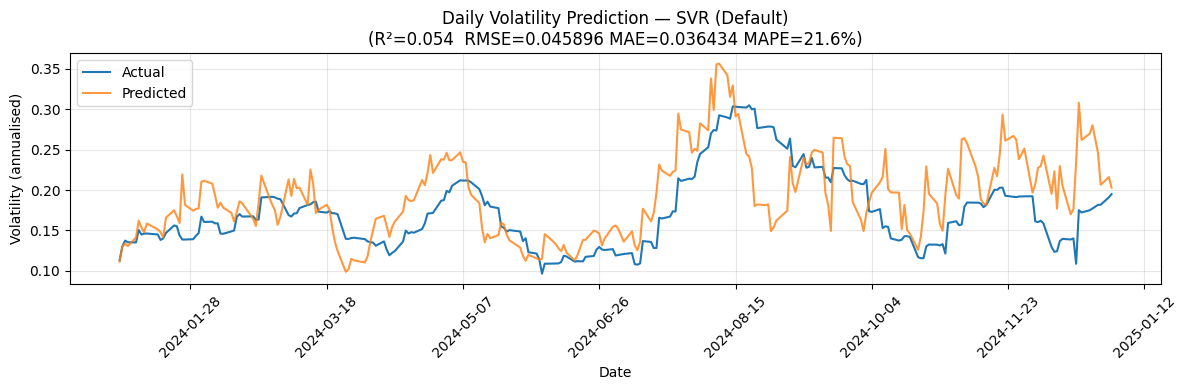

  0%|          | 0/8522 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results, rmse, mae, mape, r2, svr_fi_std, svr_fi_shap, svr_fi_perm, svr_fi_lime = Volatility_prediction(
    df, use_macro=False, model='SVR',
    use_scaling=True,
    importance_strategy='shap',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69
['PERMNO', 'BIDLO', 'ASKHI', 'PRC', 'VOL', 'RET', 'SHROUT', 'CFACPR', 'RETX', 'sprtrn', 'b30ret', 'b20ret', 'b10ret', 'b7ret', 'b5ret', 'b2ret', 'b1ret', 't90ret', 't30ret', 'cpiret', 'wti_price', 'fedfunds', 'nfci', 'anfci', 'nfci_risk', 'nfci_credit', 'nfci_leverage', 'nfci_nonfinancial_leverage', 'gdp', 'gdp_growth', 'ppi', 'unrate', 'usd_index', 'trade_balance', 'daily_range', 'volume_change', 'close_lag1', 'return_lag1', 'volatility_lag1', 'volatility_lag2', 'volatility_lag3', 'volatility_lag5', 'volatility_lag10', 'b30ret_lag1', 'b20ret_lag1', 'b10ret_lag1', 'b7ret_lag1', 'b5ret_lag1', 'b2ret_lag1', 'b1ret_lag1', 't90ret_lag1', 't30ret_lag1', 'cpiret_lag1', 'wti_price_lag1', 'fedfunds_lag1', 'nfci_lag1', 'anfci_lag1', 'nfci_risk_lag1', 'nfci_credit_lag1', 'nfci_leverage_lag1', 'nfci_nonfinancial_leverage_lag1', 'gdp_lag1', 'ppi_lag1', 'trade_balance_lag1', 'unrate_lag1', 'usd_index_lag1', 'volatility_roll5', 'volatility_roll10'

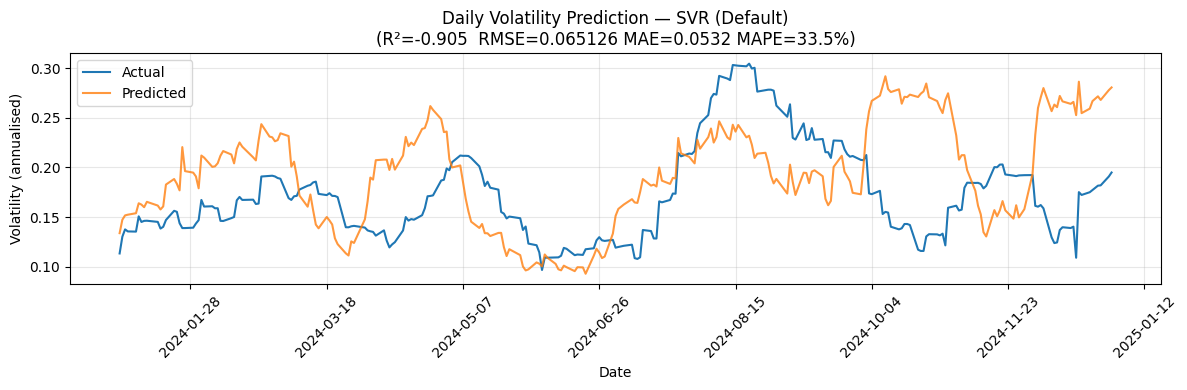

KeyboardInterrupt: 

In [ ]:
results, rmse, mae, mape, r2, svr_fi_std, svr_fi_shap, svr_fi_perm, svr_fi_lime = Volatility_prediction(
    df, use_macro=True, model='SVR',
    use_scaling=True,
    importance_strategy='lime',
    tune=False
)

### Catboost

Total: 8774 | Train: 8522 | Test: 252 | Features: 22

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.110439     0.002781
2024-02-01          0.167210     0.142317     0.024893
2024-03-04          0.169070     0.154512     0.014558
2024-04-03          0.135562     0.141034     0.005472
2024-05-02          0.197198     0.181381     0.015817
2024-06-03          0.121509     0.148001     0.026492
2024-07-03          0.119741     0.151534     0.031793
2024-08-02          0.244631     0.224868     0.019762
2024-09-03          0.251129     0.238949     0.012180
2024-10-02          0.212546     0.203168     0.009378
2024-10-31          0.121384     0.147014     0.025630
2024-12-02          0.192293     0.147624     0.044670
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.024335
             

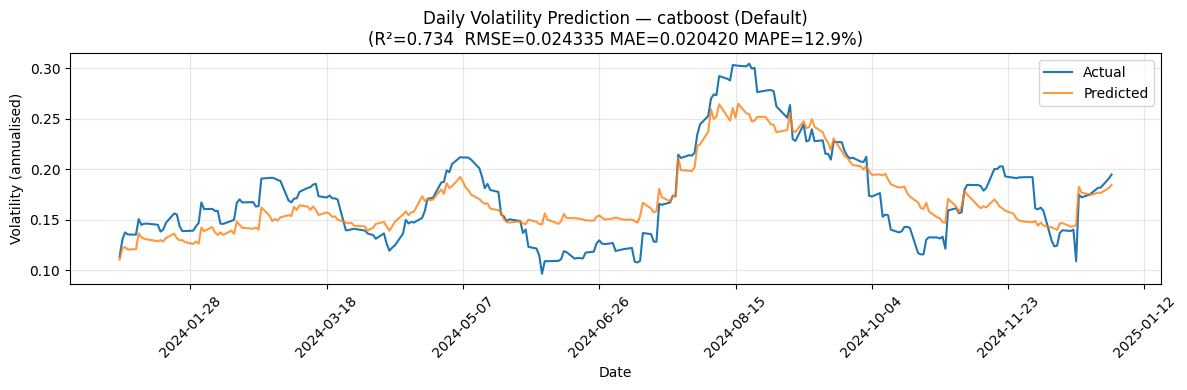

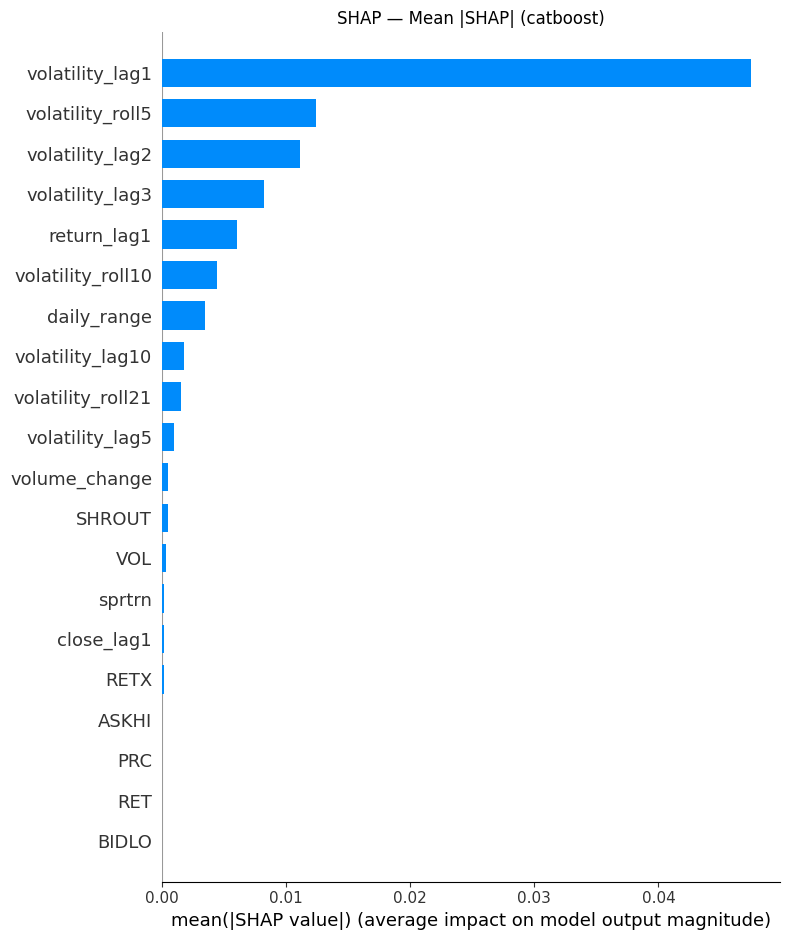

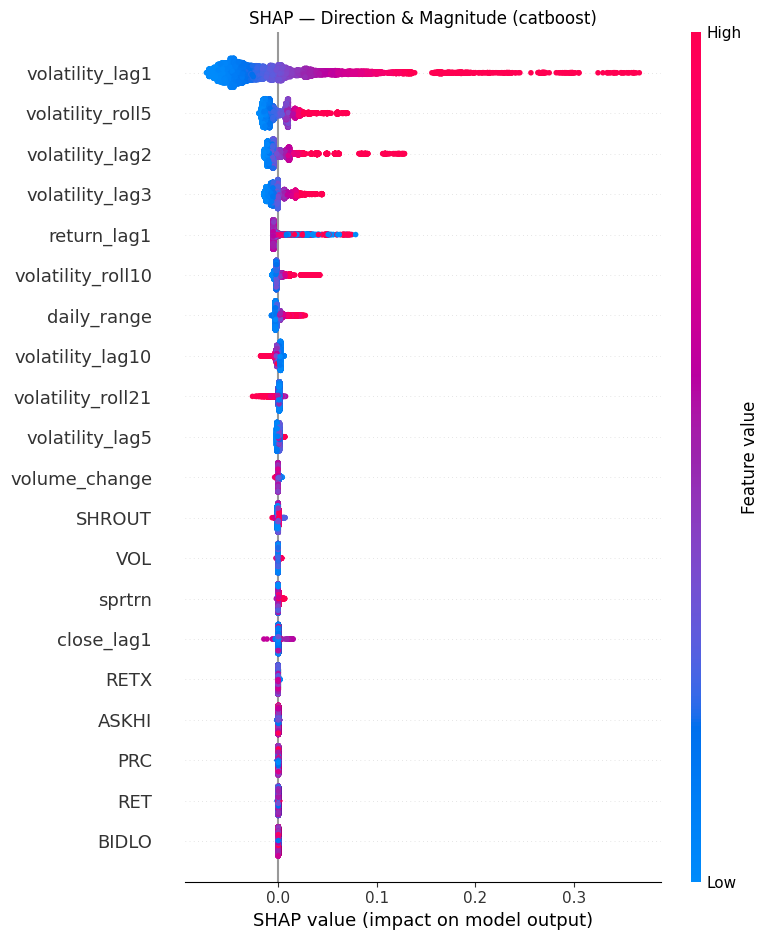

In [ ]:
results, rmse, mae, mape, r2, catboost_fi_std, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime = Volatility_prediction(
    df, use_macro=False, model='catboost',
    use_scaling=True, importance_strategy='shap',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.114187     0.000967
2024-02-01          0.167210     0.125907     0.041303
2024-03-04          0.169070     0.124664     0.044406
2024-04-03          0.135562     0.124310     0.011252
2024-05-02          0.197198     0.132379     0.064819
2024-06-03          0.121509     0.131333     0.009824
2024-07-03          0.119741     0.128129     0.008389
2024-08-02          0.244631     0.161960     0.082671
2024-09-03          0.251129     0.209248     0.041881
2024-10-02          0.212546     0.183441     0.029106
2024-10-31          0.121384     0.187537     0.066153
2024-12-02          0.192293     0.184249     0.008044
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.043246
             

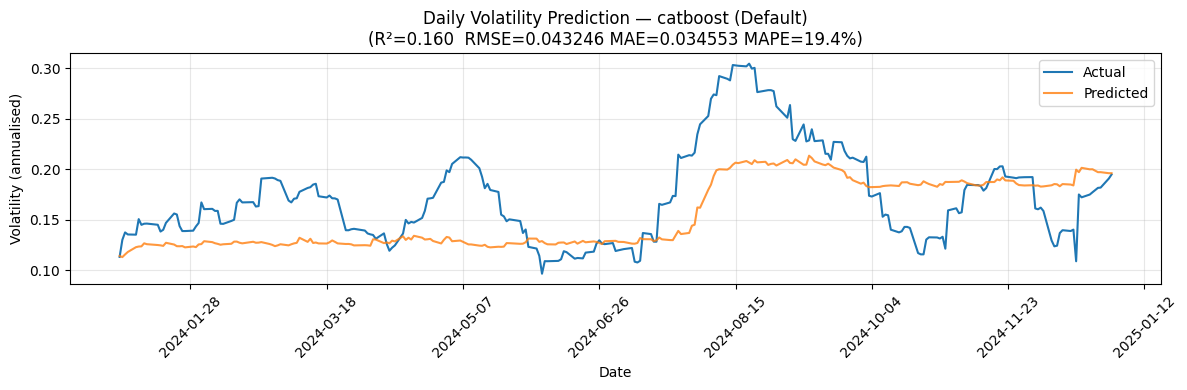

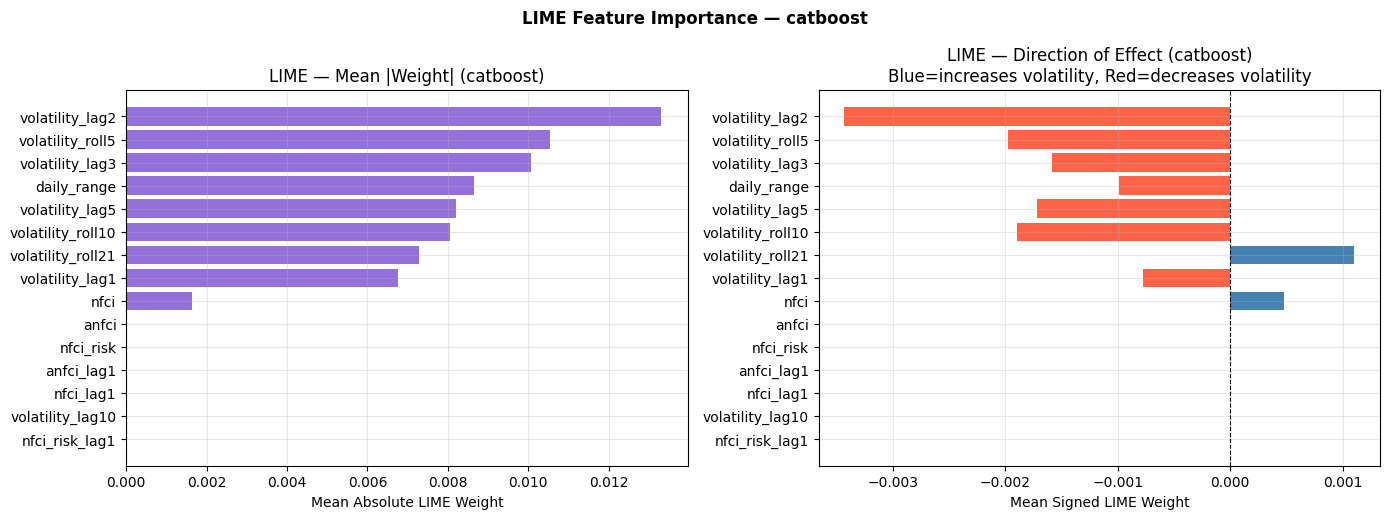

In [ ]:
results, rmse, mae, mape, r2, catboost_fi_std, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime = Volatility_prediction(
    df, use_macro=True, model='catboost',
    use_scaling=True, feature_selection=True,
    importance_strategy='lime',
    tune=False
)

### Arima

Total: 8774 | Train: 8522 | Test: 252 | Features: 22
['PERMNO', 'BIDLO', 'ASKHI', 'PRC', 'VOL', 'RET', 'SHROUT', 'CFACPR', 'RETX', 'sprtrn', 'daily_range', 'volume_change', 'close_lag1', 'return_lag1', 'volatility_lag1', 'volatility_lag2', 'volatility_lag3', 'volatility_lag5', 'volatility_lag10', 'volatility_roll5', 'volatility_roll10', 'volatility_roll21']


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARIMA — Best AIC: -49662.51
                                        RMSE:     0.077348
                                         MAE:      0.061593
                                    MAPE (%):        31.35
                                          R²:      -1.6877
Inference time: 6.304 ms

Note: ARIMA feature importance not applicable — AR/MA coefficients:
ar.L1      0.857525
ma.L1     -0.762540
ar.S.L5    0.012117
sigma2     0.000171
dtype: float64


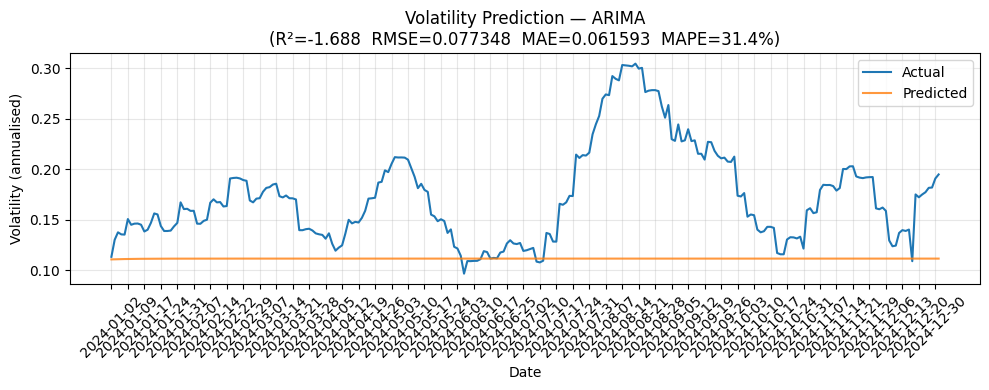

In [ ]:
results, rmse, mae, mape, r2 = Volatility_prediction(
    df, use_macro=False, model='arima',
    use_scaling=True
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69
['PERMNO', 'BIDLO', 'ASKHI', 'PRC', 'VOL', 'RET', 'SHROUT', 'CFACPR', 'RETX', 'sprtrn', 'b30ret', 'b20ret', 'b10ret', 'b7ret', 'b5ret', 'b2ret', 'b1ret', 't90ret', 't30ret', 'cpiret', 'wti_price', 'fedfunds', 'nfci', 'anfci', 'nfci_risk', 'nfci_credit', 'nfci_leverage', 'nfci_nonfinancial_leverage', 'gdp', 'gdp_growth', 'ppi', 'unrate', 'usd_index', 'trade_balance', 'daily_range', 'volume_change', 'close_lag1', 'return_lag1', 'volatility_lag1', 'volatility_lag2', 'volatility_lag3', 'volatility_lag5', 'volatility_lag10', 'b30ret_lag1', 'b20ret_lag1', 'b10ret_lag1', 'b7ret_lag1', 'b5ret_lag1', 'b2ret_lag1', 'b1ret_lag1', 't90ret_lag1', 't30ret_lag1', 'cpiret_lag1', 'wti_price_lag1', 'fedfunds_lag1', 'nfci_lag1', 'anfci_lag1', 'nfci_risk_lag1', 'nfci_credit_lag1', 'nfci_leverage_lag1', 'nfci_nonfinancial_leverage_lag1', 'gdp_lag1', 'ppi_lag1', 'trade_balance_lag1', 'unrate_lag1', 'usd_index_lag1', 'volatility_roll5', 'volatility_roll10'

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


ARIMA — Best AIC: -49620.30
                                        RMSE:     0.072012
                                         MAE:      0.056475
                                    MAPE (%):        28.54
                                          R²:      -1.3296
Inference time: 13.171 ms

Note: ARIMA feature importance not applicable — AR/MA coefficients:
x1         8.125169e-02
x2        -1.683198e-01
x3         1.248420e-02
x4        -3.751805e-02
x5         1.316689e-02
x6        -1.466128e-01
x7         1.223054e+00
x8         1.250170e+00
x9        -1.730901e+00
x10        3.618910e-01
x11       -3.616663e-04
x12        2.276549e-03
x13        1.078774e-01
x14       -1.008414e-02
x15       -6.518910e-02
x16       -2.285351e-02
x17       -1.486459e-03
x18       -1.095185e-02
x19        6.881821e-06
x20        4.148069e-04
x21       -8.865405e-14
x22        2.383315e-03
x23       -6.738193e-04
ar.L1      4.229363e-01
ar.L2      1.038966e-01
ma.L1     -3.524363e-01
ar.S.L5    7.61

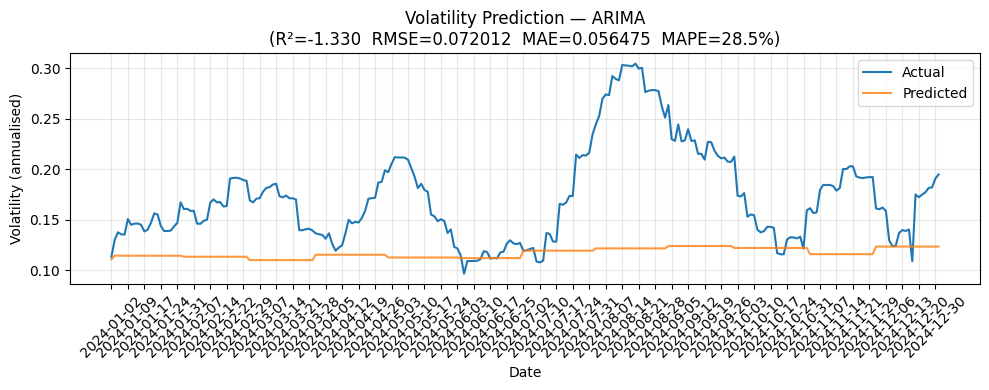

In [ ]:
results, rmse, mae, mape, r2 = Volatility_prediction(
    df, use_macro=True, model='arima',
    use_scaling=True,
    tune=False,
)

## Aggregate feature importance

In [ ]:
bayes_fi_shap

,feature,importance
0,volatility_lag1,0.080977
1,volatility_roll5,0.012942
2,nfci,0.008976
3,nfci_lag1,0.008642
4,volatility_lag3,0.007654
5,volatility_roll10,0.005378
6,volatility_lag2,0.003224
7,volatility_roll21,0.003203
8,daily_range,0.002272
9,volatility_lag5,0.002060


In [ ]:
importance_results = {'catboost':catboost_fi_shap, 'xgb':xgb_fi_shap, 'gb': gb_fi_shap, 'bayes': bayes_fi_shap}


In [ ]:
for model_name, df in importance_results.items():
    df.to_csv(f"/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/{model_name}_shap_importance_volatility.csv", index=False)

In [ ]:
import glob
import os
import pandas as pd


for file in glob.glob(os.path.join("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data", "*_lime_importance_Volatility.csv")): # and also load files that end with _shap_importance_cpi
    model_name = os.path.basename(file).replace("_lime_importance_Volatility.csv", "")
    importance_results[model_name] = pd.read_csv(file)

# Check what was loaded
print(importance_results.keys())

In [ ]:
def _classify(feature: str) -> str:
    base = feature.replace("_lag1", "").replace("_lag2", "").replace("_lag4", "")
    return "macro" if base in macro_vars else "micro"

def _build_matrices(importance_results: dict):
    model_names  = list(importance_results.keys())
    n_models     = len(model_names)

    all_features = sorted(
        set(f for fi in importance_results.values() for f in fi['feature'])
    )
    n_features = len(all_features)

    rank_matrix  = pd.DataFrame(index=all_features, columns=model_names, dtype=float)
    score_matrix = pd.DataFrame(index=all_features, columns=model_names, dtype=float)

    for model_name, fi_df in importance_results.items():
        fi_df = fi_df.copy().reset_index(drop=True)
        fi_df['rank'] = fi_df['importance'].rank(ascending=False, method='min')

        imp_min = fi_df['importance'].min()
        imp_max = fi_df['importance'].max()
        denom   = imp_max - imp_min if imp_max != imp_min else 1.0
        fi_df['norm_score'] = (fi_df['importance'] - imp_min) / denom

        for _, row in fi_df.iterrows():
            rank_matrix.loc[row['feature'],  model_name] = row['rank']
            score_matrix.loc[row['feature'], model_name] = row['norm_score']

        for f in set(all_features) - set(fi_df['feature']):
            rank_matrix.loc[f,  model_name] = n_features + 1
            score_matrix.loc[f, model_name] = 0.0

    return model_names, all_features, n_features, rank_matrix, score_matrix


>>> LIME — volatility: ['catboost', 'xgb', 'gb', 'svr', 'bayes', 'knn']

MODEL AGREEMENT — Top 15 features per model
  volatility_lag2                ██████     6/6 (100%)  [micro]
  volatility_lag3                ██████     6/6 (100%)  [micro]
  volatility_lag5                ██████     6/6 (100%)  [micro]
  volatility_roll10              ██████     6/6 (100%)  [micro]
  volatility_roll5               █████      5/6 (83%)  [micro]
  daily_range                    █████      5/6 (83%)  [micro]
  volatility_roll21              █████      5/6 (83%)  [micro]
  volatility_lag1                █████      5/6 (83%)  [micro]
  ASKHI                          █████      5/6 (83%)  [micro]
  PRC                            █████      5/6 (83%)  [micro]
  close_lag1                     ████       4/6 (67%)  [micro]
  VOL                            ████       4/6 (67%)  [micro]
  return_lag1                    ████       4/6 (67%)  [micro]
  volume_change                  ████       4/6 (67%)  [mic

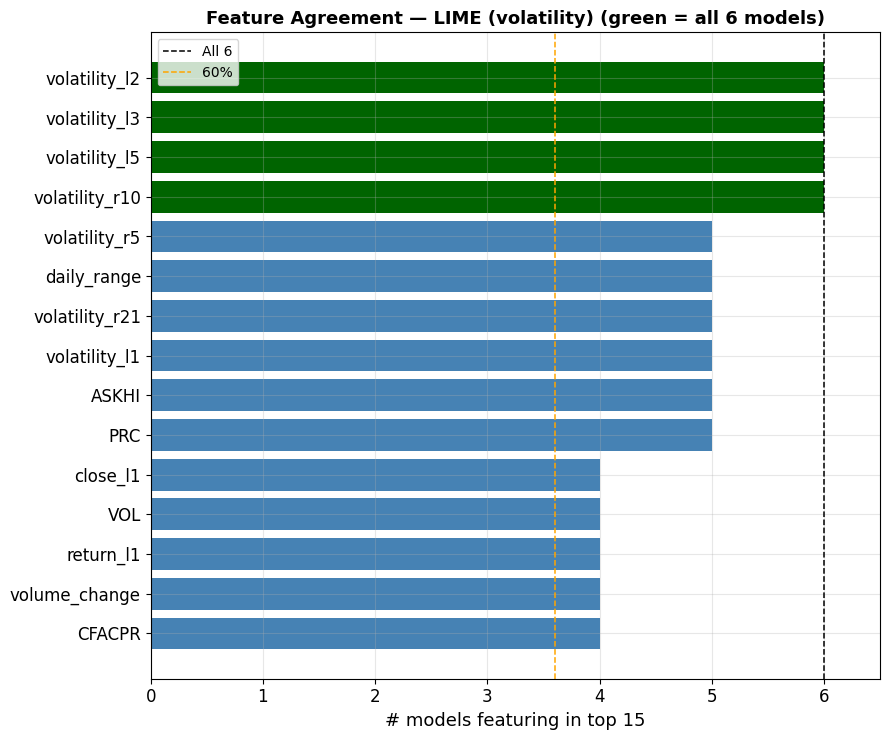


>>> SHAP — volatility: ['catboost', 'xgb', 'gb', 'bayes']

MODEL AGREEMENT — Top 15 features per model
  volatility_lag1                ████       4/4 (100%)  [micro]
  volatility_roll5               ████       4/4 (100%)  [micro]
  volatility_lag2                ████       4/4 (100%)  [micro]
  volatility_lag3                ████       4/4 (100%)  [micro]
  volatility_roll10              ████       4/4 (100%)  [micro]
  daily_range                    ████       4/4 (100%)  [micro]
  volatility_lag10               ████       4/4 (100%)  [micro]
  volatility_roll21              ████       4/4 (100%)  [micro]
  volatility_lag5                ████       4/4 (100%)  [micro]
  return_lag1                    ███        3/4 (75%)  [micro]
  volume_change                  ███        3/4 (75%)  [micro]
  sprtrn                         ███        3/4 (75%)  [micro]
  SHROUT                         ██         2/4 (50%)  [micro]
  VOL                            ██         2/4 (50%)  [micro]
  clo

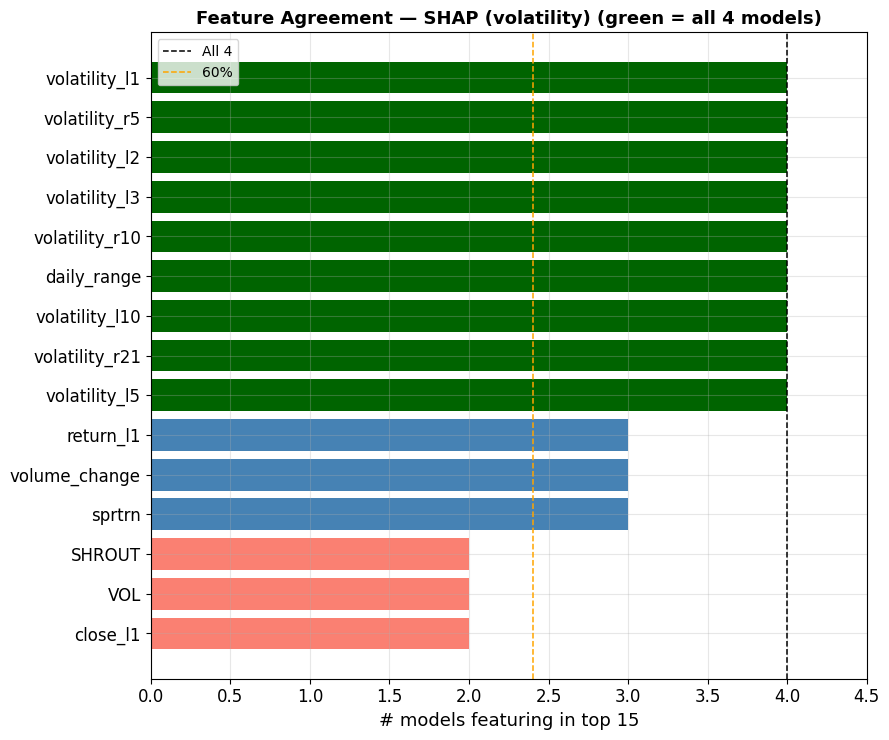

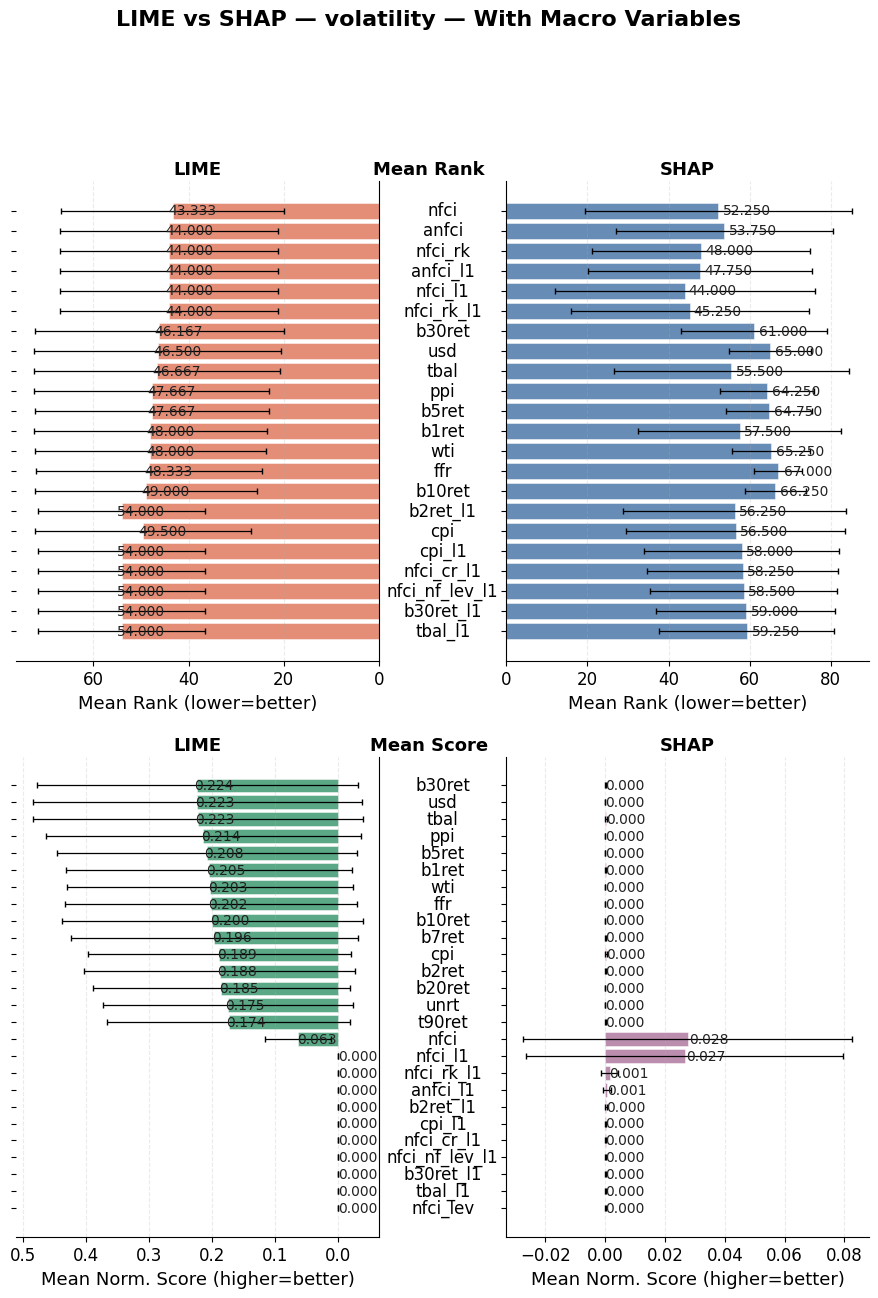

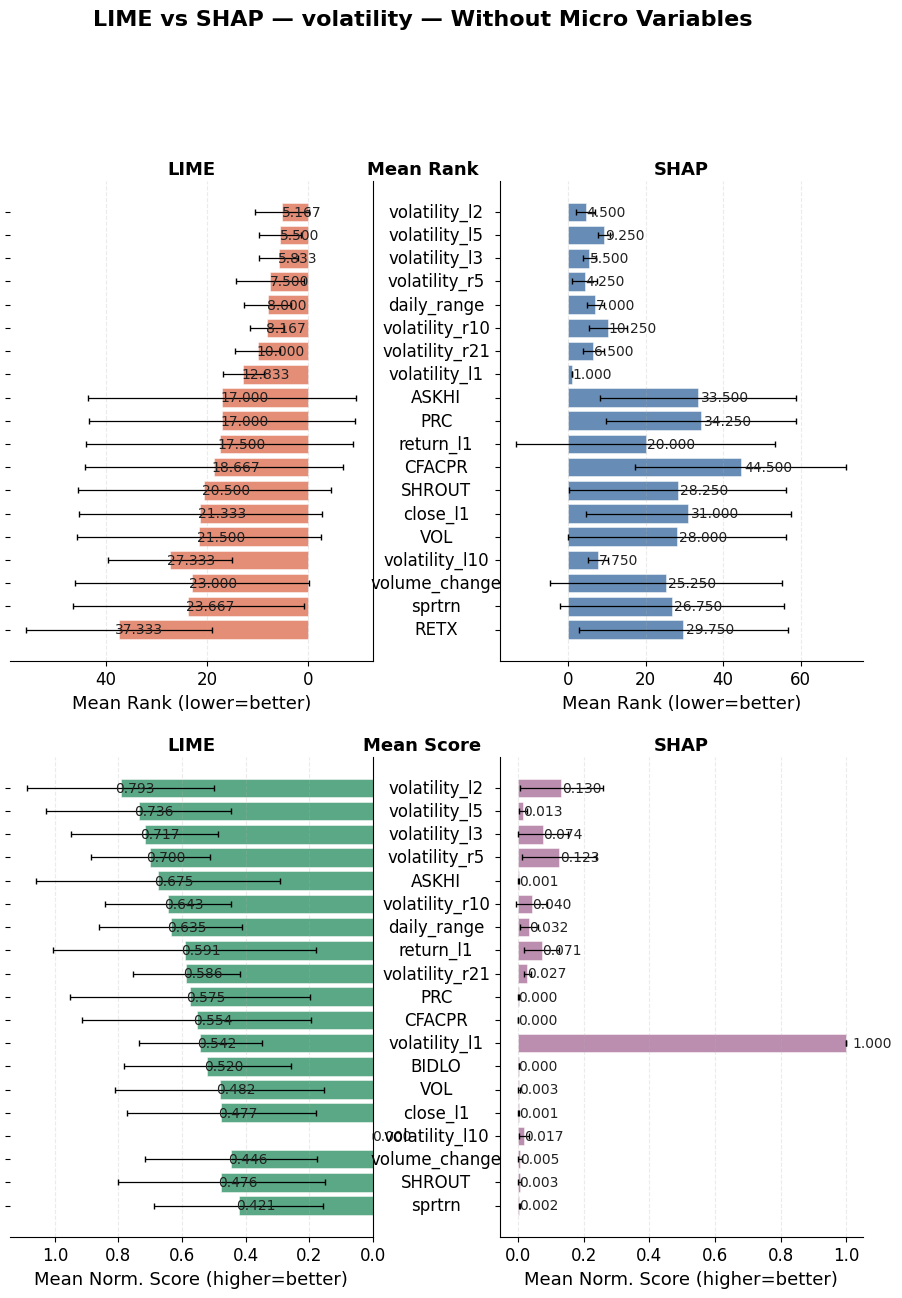

In [ ]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

_SHORTEN_PATTERNS = [
    (r'_lag(\d+)', r'_l\1'),
    (r'_roll(\d+)', r'_r\1'),
    (r'nonfinancial_leverage', 'nonfin_lev'),
    (r'leverage', 'lev'),
    (r'trade_balance', 'tbal'),
    (r'gdp_growth', 'gdp_gr'),
    (r'wti_price', 'wti'),
    (r'usd_index', 'usd'),
    (r'fedfunds', 'ffr'),
    (r'nfci_credit', 'nfci_cr'),
    (r'nfci_risk', 'nfci_rk'),
    (r'nfci_nonfin', 'nfci_nf'),
    (r'cpiret', 'cpi'),
    (r'unrate', 'unrt'),
    (r'working_age_pop', 'wap'),
    (r'labor_force_women', 'lf_women'),
    (r'labor_force_men', 'lf_men'),
    (r'labor_force_part', 'lf_part'),
    (r'health_services_emp', 'health_emp'),
    (r'homeownership_rate', 'home_own'),
]

def _shorten_label(feat: str) -> str:
    s = feat
    for pat, rep in _SHORTEN_PATTERNS:
        s = re.sub(pat, rep, s)
    return s.rstrip('_')


def _compute_all_methods(model_names, all_features, n_features,
                          rank_matrix, score_matrix) -> pd.DataFrame:
    borda_scores = sum(
        (n_features + 1) - rank_matrix[m] for m in model_names
    )
    mean_rank = rank_matrix.mean(axis=1)
    std_rank  = rank_matrix.std(axis=1)
    mean_score = score_matrix.mean(axis=1)
    std_score  = score_matrix.std(axis=1)

    combined = pd.DataFrame({
        'feature':          all_features,
        'borda_score':      borda_scores.values,
        'mean_rank':        mean_rank.values,
        'std_rank':         std_rank.values,
        'mean_score':       mean_score.values,
        'std_score':        std_score.values,
        'consistency':      (1 / (std_rank.values + 1e-6)),
        'var_group':        [_classify(f) for f in all_features],
    })
    return combined


def _compute_combined_df(importance_results: dict) -> pd.DataFrame:
    model_names, all_features, n_features, rank_matrix, score_matrix = \
        _build_matrices(importance_results)
    return _compute_all_methods(
        model_names, all_features, n_features, rank_matrix, score_matrix
    )

FS_TITLE    = 13
FS_SUPTITLE = 16
FS_LABEL    = 13
FS_TICK     = 12
FS_VALUE    = 10

DEFAULT_TOP_N = 15


def _build_shared_feature_order_across_methods(combined_lime, combined_shap,
                                                group_key, sort_col,
                                                ascending, top_n):
    lime_subset = (combined_lime[combined_lime['var_group'] == group_key]
                   .sort_values(sort_col, ascending=ascending)
                   .head(top_n))
    shap_subset = (combined_shap[combined_shap['var_group'] == group_key]
                   .sort_values(sort_col, ascending=ascending)
                   .head(top_n))

    lime_feats = lime_subset['feature'].tolist()
    shap_feats = shap_subset['feature'].tolist()

    shared_order = list(dict.fromkeys(lime_feats + shap_feats))
    return shared_order

def _plot_tornado_row(fig, gs_row, shared_features, combined_lime, combined_shap,
                       group_key, score_col, err_col, xlabel,
                       color_lime, color_shap, row_title):
    ax_left  = fig.add_subplot(gs_row[0])
    ax_mid   = fig.add_subplot(gs_row[1])
    ax_right = fig.add_subplot(gs_row[2], sharey=ax_left)

    lookup_lime = combined_lime[combined_lime['var_group'] == group_key].set_index('feature')
    lookup_shap = combined_shap[combined_shap['var_group'] == group_key].set_index('feature')

    scores_lime, errs_lime, in_lime = [], [], []
    scores_shap, errs_shap, in_shap = [], [], []
    for feat in shared_features:
        if feat in lookup_lime.index:
            scores_lime.append(lookup_lime.loc[feat, score_col])
            errs_lime.append(lookup_lime.loc[feat, err_col] if err_col else 0)
            in_lime.append(True)
        else:
            scores_lime.append(0.0)
            errs_lime.append(0.0)
            in_lime.append(False)

        if feat in lookup_shap.index:
            scores_shap.append(lookup_shap.loc[feat, score_col])
            errs_shap.append(lookup_shap.loc[feat, err_col] if err_col else 0)
            in_shap.append(True)
        else:
            scores_shap.append(0.0)
            errs_shap.append(0.0)
            in_shap.append(False)

    # reverse so top-ranked feature is at the top of the chart
    shared_r    = shared_features[::-1]
    scores_lime = scores_lime[::-1]; errs_lime = errs_lime[::-1]; in_lime = in_lime[::-1]
    scores_shap = scores_shap[::-1]; errs_shap = errs_shap[::-1]; in_shap = in_shap[::-1]

    display_features = [_shorten_label(f) for f in shared_r]
    y = range(len(shared_r))

    ax_left.barh(list(y), scores_lime, xerr=errs_lime if err_col else None,
                 color=color_lime, alpha=0.85, capsize=2.5,
                 error_kw={'linewidth': 0.9}, edgecolor='white', linewidth=0.4)
    ax_left.invert_xaxis()
    ax_left.set_yticks(list(y))
    ax_left.set_yticklabels([])   # no labels here — middle panel owns them
    ax_left.set_xlabel(xlabel, fontsize=FS_LABEL)
    ax_left.set_title("LIME", fontsize=FS_TITLE, fontweight='bold', pad=5)
    ax_left.tick_params(axis='x', labelsize=FS_TICK)
    ax_left.grid(True, axis='x', alpha=0.25, linestyle='--')
    ax_left.spines[['top', 'left']].set_visible(False)
    for i, (s, ok) in enumerate(zip(scores_lime, in_lime)):
        if not ok:
            continue
        ax_left.text(s * 1.02, i, f"{s:.3f}", va='center', ha='left',
                     fontsize=FS_VALUE, color='#222222')

    ax_mid.set_xlim(0, 1)
    ax_mid.set_ylim(ax_left.get_ylim())
    for i, feat in enumerate(display_features):
        ax_mid.text(0.5, i, feat, va='center', ha='center', fontsize=FS_TICK)
    ax_mid.axis('off')

    ax_right.barh(list(y), scores_shap, xerr=errs_shap if err_col else None,
                  color=color_shap, alpha=0.85, capsize=2.5,
                  error_kw={'linewidth': 0.9}, edgecolor='white', linewidth=0.4)
    ax_right.set_yticks(list(y))
    ax_right.set_yticklabels([])
    ax_right.set_xlabel(xlabel, fontsize=FS_LABEL)
    ax_right.set_title("SHAP", fontsize=FS_TITLE, fontweight='bold', pad=5)
    ax_right.tick_params(axis='x', labelsize=FS_TICK)
    ax_right.grid(True, axis='x', alpha=0.25, linestyle='--')
    ax_right.spines[['top', 'right']].set_visible(False)
    for i, (s, ok) in enumerate(zip(scores_shap, in_shap)):
        if not ok:
            continue
        ax_right.text(s * 1.02, i, f"{s:.3f}", va='center', ha='left',
                      fontsize=FS_VALUE, color='#222222')

    for i, (ok_l, ok_s) in enumerate(zip(in_lime, in_shap)):
        if not (ok_l and ok_s):
            ax_mid.texts[i].set_color('#bbbbbb')

    # row-level shared title above the trio
    fig.text(0.5, ax_mid.get_position().y1 + 0.002, row_title,
          ha='center', va='bottom', fontsize=FS_TITLE, fontweight='bold',
          transform=fig.transFigure)


def plot_group_comparison_tornado(method_results: dict, group_key: str,
                                   group_label: str, top_n: int = DEFAULT_TOP_N,
                                   save_name: str = "comparison.png",
                                   suptitle: str = "Feature Importance Comparison"):
    combined_lime = _compute_combined_df(method_results['lime'])
    combined_shap = _compute_combined_df(method_results['shap'])

    METRIC_CFG = [
        ('mean_rank', True, 'mean_rank', 'std_rank',
         'Mean Rank (lower=better)', '#E07A5F', '#4C78A8', 'Mean Rank'),
        ('mean_score', False, 'mean_score', 'std_score',
         'Mean Norm. Score (higher=better)', '#3D9970', '#B07AA1', 'Mean Score'),
    ]

    n_rows = len(METRIC_CFG)
    fig_height = n_rows * (top_n * 2 * 0.20 + 0.6)
    fig = plt.figure(figsize=(11, fig_height), constrained_layout=False)

    outer_gs = gridspec.GridSpec(n_rows, 1, figure=fig, hspace=0.20,
                              top=0.85, bottom=0.05)

    fig.suptitle(f"{suptitle} — {group_label}",
             fontsize=FS_SUPTITLE, fontweight='bold', y=0.98)

    for row_idx, (sort_col, ascending, score_col, err_col,
                  xlabel, color_lime, color_shap, metric_label) in enumerate(METRIC_CFG):

        shared_features = _build_shared_feature_order_across_methods(
            combined_lime, combined_shap, group_key, sort_col, ascending, top_n
        )

        row_gs = gridspec.GridSpecFromSubplotSpec(
            1, 3, subplot_spec=outer_gs[row_idx],
            width_ratios=[1, 0.32, 1], wspace=0.02
        )

        _plot_tornado_row(fig, row_gs, shared_features, combined_lime, combined_shap,
                           group_key, score_col, err_col, xlabel,
                           color_lime, color_shap, metric_label)

    plt.savefig(save_name, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    return combined_lime, combined_shap


def plot_model_agreement(importance_results: dict, top_n: int = DEFAULT_TOP_N,
                          save_name: str = "model_agreement.png",
                          title_prefix: str = "Feature Agreement"):
    model_names = list(importance_results.keys())
    vote_counts = {}

    for model_name, fi_df in importance_results.items():
        for f in fi_df.nlargest(top_n, 'importance')['feature']:
            vote_counts[f] = vote_counts.get(f, 0) + 1

    vote_df = (pd.DataFrame({
        'feature': list(vote_counts.keys()),
        'votes':   list(vote_counts.values()),
        'group':   [_classify(f) for f in vote_counts]
    }).sort_values('votes', ascending=False).head(top_n).reset_index(drop=True))

    print(f"\n{'='*55}")
    print(f"MODEL AGREEMENT — Top {top_n} features per model")
    print(f"{'='*55}")
    for _, row in vote_df.iterrows():
        bar = '█' * row['votes']
        pct = row['votes'] / len(model_names) * 100
        print(f"  {row['feature']:<30} {bar:<10} "
              f"{row['votes']}/{len(model_names)} ({pct:.0f}%)  [{row['group']}]")
    print(f"{'='*55}")

    display_features = [_shorten_label(f) for f in vote_df['feature']]

    fig, ax = plt.subplots(figsize=(9, max(3.5, len(vote_df) * 0.5)))
    colors = ['darkgreen' if v == len(model_names)
              else 'steelblue' if v >= len(model_names) * 0.6
              else 'salmon'
              for v in vote_df['votes'][::-1]]
    ax.barh(display_features[::-1], vote_df['votes'][::-1], color=colors)
    ax.axvline(len(model_names), color='black', linestyle='--',
               linewidth=1.1, label=f'All {len(model_names)}')
    ax.axvline(len(model_names) * 0.6, color='orange', linestyle='--',
               linewidth=1.1, label='60%')
    ax.set_xlabel(f"# models featuring in top {top_n}", fontsize=FS_LABEL)
    ax.set_title(f"{title_prefix} (green = all {len(model_names)} models)",
                 fontsize=FS_TITLE, fontweight='bold')
    ax.tick_params(labelsize=FS_TICK)
    ax.set_xlim(0, len(model_names) + 0.5)
    ax.legend(fontsize=FS_TICK - 2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    return vote_df


DATA_DIR = "/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data"

TARGETS = ["volatility"]
METHODS = ["lime", "shap"]

all_vote_dfs = {}

for target in TARGETS:
    method_results = {}
    for method in METHODS:
        pattern = os.path.join(DATA_DIR, f"*_{method}_importance_{target}.csv")
        files = glob.glob(pattern)

        importance_results = {}
        for file in files:
            model_name = os.path.basename(file).replace(
                f"_{method}_importance_{target}.csv", ""
            )
            importance_results[model_name] = pd.read_csv(file)

        print(f"\n>>> {method.upper()} — {target}: {list(importance_results.keys())}")

        if not importance_results:
            print(f"    No files found for pattern: {pattern}")
            continue

        method_results[method] = importance_results

        all_vote_dfs[f"{method}_{target}"] = plot_model_agreement(
            importance_results,
            top_n=DEFAULT_TOP_N,
            save_name=f"model_agreement_{method}_{target}.png",
            title_prefix=f"Feature Agreement — {method.upper()} ({target})"
        )

    if len(method_results) == 2:
        plot_group_comparison_tornado(
            method_results, group_key='macro', group_label='With Macro Variables',
            top_n=DEFAULT_TOP_N,
            save_name=f"comparison_{target}_macro.png",
            suptitle=f"LIME vs SHAP — {target}"
        )
        plot_group_comparison_tornado(
            method_results, group_key='micro', group_label='Without Micro Variables',
            top_n=DEFAULT_TOP_N,
            save_name=f"comparison_{target}_micro.png",
            suptitle=f"LIME vs SHAP — {target}"
        )